In [2]:
!python -m pip install xgboost catboost scikit-learn matplotlib seaborn geopandas pandas numpy scipy 


In [56]:

#!pip -q install xgboost

import os, glob, zipfile, warnings, shutil
import tkinter as tk
from tkinter import filedialog
import numpy as np
import pandas as pd
import seaborn as sns
from numpy import trapezoid
from scipy import integrate
#from google.colab import files
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import geopandas as gpd
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.colors as mcolors





warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

from google.colab import files

print("Upload your GEE ZIP or CSVs + yield CSV")
uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError("❌ No files uploaded")

print("Uploaded files:", list(uploaded.keys()))

In [4]:


# 1. SETUP LOCAL DIRECTORY
# This creates a 'data' folder in the same folder where your script is running
DATA_DIR = os.path.join(os.getcwd(), "data")
os.makedirs(DATA_DIR, exist_ok=True)

# 2. SELECT FILES (OFFLINE REPLACEMENT FOR files.upload)
root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

print("Select your GEE ZIP or CSVs + yield CSV")
file_paths = filedialog.askopenfilenames(
    title="Select Data Files",
    filetypes=[("Data files", "*.csv *.zip"), ("All files", "*.*")]
)

if not file_paths:
    raise ValueError("❌ No files selected")

# -----------------------------
# CLASSIFY AND PROCESS FILES
# -----------------------------
# We iterate directly through the paths you picked on your computer
for src_path in file_paths:
    filename = os.path.basename(src_path)
    
    # Handle ZIP files
    if filename.lower().endswith(".zip"):
        print(f"Extracting: {filename}")
        with zipfile.ZipFile(src_path, 'r') as z:
            z.extractall(DATA_DIR)
            
    # Handle CSV files
    elif filename.lower().endswith(".csv"):
        dst_path = os.path.join(DATA_DIR, filename)
        if not os.path.exists(dst_path):
            # We use copy2 to keep the original file where it was 
            # and put a copy in our data folder
            shutil.copy2(src_path, dst_path)
            print(f"Copied: {filename}")
        else:
            print(f"Skipped (already exists): {filename}")

# -----------------------------
# FIND ALL CSV FILES
# -----------------------------
# Look inside our local DATA_DIR for everything extracted/copied
all_csvs = glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True)

print(f"\n✅ Total CSV files found: {len(all_csvs)}")
for f in all_csvs[:10]:
    print(" -", f)

if len(all_csvs) == 0:
    print(f"\n⚠️ No files found in {DATA_DIR}. Please check the folder manually.")

Select your GEE ZIP or CSVs + yield CSV
Extracting: drive-download-20260408T052345Z-3-001 (1).zip

✅ Total CSV files found: 25
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_Illinois.csv
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_Indiana.csv
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_Iowa.csv
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_Kansas.csv
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_Michigan.csv
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_Minnesota.csv
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_Missouri.csv
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_Nebraska.csv
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_North_Dakota.csv
 - c:\Users\logan\OneDrive\BSE 508\data\Corn_MODIS_lagged_Ohio.csv


import os, glob, zipfile, shutil

DATA_DIR = "/content/data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_files = []
csv_files_uploaded = []

# -----------------------------
# CLASSIFY FILES
# -----------------------------
for filename in uploaded.keys():
    src = os.path.join("/content", filename)

    if filename.lower().endswith(".zip"):
        zip_files.append(src)

    elif filename.lower().endswith(".csv"):
        csv_files_uploaded.append(src)

# -----------------------------
# EXTRACT ZIP FILES
# -----------------------------
for path in zip_files:
    print("Extracting:", os.path.basename(path))
    with zipfile.ZipFile(path, 'r') as z:
        z.extractall(DATA_DIR)

# -----------------------------
# MOVE CSV FILES INTO DATA_DIR
# -----------------------------
for f in csv_files_uploaded:
    dst = os.path.join(DATA_DIR, os.path.basename(f))

    if not os.path.exists(dst):  # avoid overwrite crash
        shutil.move(f, dst)

# -----------------------------
# FIND ALL CSV FILES (FIXED)
# -----------------------------
all_csvs = glob.glob(DATA_DIR + "/**/*.csv", recursive=True)

print("\n✅ Total CSV files found:", len(all_csvs))
for f in all_csvs[:10]:
    print(" -", f)

# -----------------------------
# DEBUG: if still empty
# -----------------------------
if len(all_csvs) == 0:
    print("\n⚠️ No files found in DATA_DIR, checking /content instead...")

    all_csvs = glob.glob("/content/**/*.csv", recursive=True)

    print("Fallback CSV count:", len(all_csvs))
    for f in all_csvs[:10]:
        print(" -", f)

In [5]:
# ============================================================
# CELL 1 — FIND SAME-YEAR VS LAGGED-CDL FILES
# Put this directly after all_csvs has been created
# ============================================================

same_year_csvs = [
    f for f in all_csvs
    if "Corn_MODIS" in os.path.basename(f)
    and "lag" not in os.path.basename(f).lower()
    and "prev" not in os.path.basename(f).lower()
]

lagged_csvs = [
    f for f in all_csvs
    if "Corn_MODIS" in os.path.basename(f)
    and (
        "lag" in os.path.basename(f).lower()
        or "prev" in os.path.basename(f).lower()
    )
]

print("==================================================")
print("SAME-YEAR FILES FOUND:", len(same_year_csvs))
print("==================================================")
for f in same_year_csvs[:10]:
    print(os.path.basename(f))

print("\n==================================================")
print("LAGGED-CDL FILES FOUND:", len(lagged_csvs))
print("==================================================")
for f in lagged_csvs[:10]:
    print(os.path.basename(f))

SAME-YEAR FILES FOUND: 12
Corn_MODIS_same_year_Illinois.csv
Corn_MODIS_same_year_Indiana.csv
Corn_MODIS_same_year_Iowa.csv
Corn_MODIS_same_year_Kansas.csv
Corn_MODIS_same_year_Michigan.csv
Corn_MODIS_same_year_Minnesota.csv
Corn_MODIS_same_year_Missouri.csv
Corn_MODIS_same_year_Nebraska.csv
Corn_MODIS_same_year_North_Dakota.csv
Corn_MODIS_same_year_Ohio.csv

LAGGED-CDL FILES FOUND: 12
Corn_MODIS_lagged_Illinois.csv
Corn_MODIS_lagged_Indiana.csv
Corn_MODIS_lagged_Iowa.csv
Corn_MODIS_lagged_Kansas.csv
Corn_MODIS_lagged_Michigan.csv
Corn_MODIS_lagged_Minnesota.csv
Corn_MODIS_lagged_Missouri.csv
Corn_MODIS_lagged_Nebraska.csv
Corn_MODIS_lagged_North_Dakota.csv
Corn_MODIS_lagged_Ohio.csv


In [6]:
# ============================================================
# BUILD WIDE GEE FUNCTION
# ============================================================

def build_gee_wide(csv_list):

    dfs = []

    veg_cols = [
        "NDVI_scaled",
        "EVI_scaled",
        "EVI2",
        "NIRv",
        "GCI",
        "NDWI"
    ]

    for f in csv_list:

        print("Loading:", os.path.basename(f))

        df = pd.read_csv(f, low_memory=False)
        df.columns = [c.strip() for c in df.columns]

        rename_map = {
            "NDVI": "NDVI_scaled",
            "EVI": "EVI_scaled",
            "NDWI_scaled": "NDWI"
        }

        df = df.rename(columns=rename_map)

        needed = [
            "NAME",
            "GEOID",
            "STATEFP",
            "date",
            "year",
            "NDVI_scaled",
            "EVI_scaled",
            "EVI2",
            "NIRv",
            "GCI",
            "NDWI"
        ]

        missing = [c for c in needed if c not in df.columns]

        if len(missing) > 0:
            print(f"Skipping {os.path.basename(f)}")
            print("Missing columns:", missing)
            continue

        df = df[needed].copy()

        df["GEOID"] = df["GEOID"].astype(str).str.zfill(5)
        df["STATEFP"] = pd.to_numeric(df["STATEFP"], errors="coerce")
        df["year"] = pd.to_numeric(df["year"], errors="coerce")
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["DOY"] = df["date"].dt.dayofyear

        for col in veg_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        dfs.append(df)

    gee_long = pd.concat(dfs, ignore_index=True)

    print("\nRaw long shape:", gee_long.shape)

    dup_mask = gee_long.duplicated(
        subset=["GEOID", "year", "DOY"],
        keep=False
    )

    print("Duplicate GEOID-year-DOY rows:", int(dup_mask.sum()))

    if dup_mask.sum() > 0:

        print("Collapsing duplicates...")

        gee_long = (
            gee_long
            .groupby(
                ["GEOID", "NAME", "STATEFP", "year", "DOY"],
                as_index=False
            )[veg_cols]
            .mean()
        )

    print("Shape after duplicate handling:", gee_long.shape)

    print("\n===== GEE LONG SAMPLE =====")
    display(
        gee_long[
            [
                "GEOID",
                "year",
                "DOY",
                "NDVI_scaled",
                "EVI_scaled",
                "EVI2",
                "NIRv",
                "GCI",
                "NDWI"
            ]
        ].head(15)
    )

    wide_parts = []

    for col in veg_cols:

        temp = gee_long.pivot_table(
            index=["GEOID", "year"],
            columns="DOY",
            values=col,
            aggfunc="mean"
        )

        temp.columns = [f"{col}_DOY_{int(c)}" for c in temp.columns]

        wide_parts.append(temp)

    gee_wide = pd.concat(wide_parts, axis=1).reset_index()

    print("\nWide shape:", gee_wide.shape)

    print(
        "Unique county-years:",
        gee_wide[["GEOID", "year"]].drop_duplicates().shape[0]
    )

    print("\n===== GEE WIDE SAMPLE =====")
    display(gee_wide.head())

    return gee_wide

In [7]:
# ============================================================
# CELL 3 — BUILD SAME-YEAR AND LAGGED GEE TABLES
# ============================================================

same_year_gee_wide = build_gee_wide(same_year_csvs)
lagged_gee_wide = build_gee_wide(lagged_csvs)

print("\n==================================================")
print("FINAL DATASET SHAPES")
print("==================================================")
print("Same-year GEE shape:", same_year_gee_wide.shape)
print("Lagged-CDL GEE shape:", lagged_gee_wide.shape)

Loading: Corn_MODIS_same_year_Illinois.csv
Loading: Corn_MODIS_same_year_Indiana.csv
Loading: Corn_MODIS_same_year_Iowa.csv
Loading: Corn_MODIS_same_year_Kansas.csv
Loading: Corn_MODIS_same_year_Michigan.csv
Loading: Corn_MODIS_same_year_Minnesota.csv
Loading: Corn_MODIS_same_year_Missouri.csv
Loading: Corn_MODIS_same_year_Nebraska.csv
Loading: Corn_MODIS_same_year_North_Dakota.csv
Loading: Corn_MODIS_same_year_Ohio.csv
Loading: Corn_MODIS_same_year_South_Dakota.csv
Loading: Corn_MODIS_same_year_Wisconsin.csv

Raw long shape: (269025, 12)
Duplicate GEOID-year-DOY rows: 0
Shape after duplicate handling: (269025, 12)

===== GEE LONG SAMPLE =====


,GEOID,year,DOY,NDVI_scaled,EVI_scaled,EVI2,NIRv,GCI,NDWI
0,17121,2008,65,0.336298,0.173199,0.170507,0.065372,1.552308,-0.121684
1,17005,2008,65,0.341752,0.176093,0.172854,0.066771,1.657825,-0.107758
2,17083,2008,65,0.308540,0.159671,0.156677,0.059515,1.425162,-0.165329
3,17163,2008,65,0.379428,0.211539,0.205991,0.083904,1.491300,-0.139094
4,17027,2008,65,0.405389,0.227698,0.221574,0.092160,1.801292,-0.063055
5,17013,2008,65,0.312777,0.174610,0.173032,0.068931,1.568150,-0.122594
6,17119,2008,65,0.332831,0.175712,0.171530,0.066454,1.414618,-0.132031
7,17133,2008,65,0.364860,0.197314,0.193667,0.078390,1.717203,-0.113226
8,17117,2008,65,0.290229,0.135075,0.132253,0.047400,1.371716,-0.134044
9,17171,2008,65,0.274233,0.140252,0.138562,0.051452,1.222068,-0.175583



Wide shape: (17693, 92)
Unique county-years: 17693

===== GEE WIDE SAMPLE =====


,GEOID,year,NDVI_scaled_DOY_65,NDVI_scaled_DOY_81,NDVI_scaled_DOY_97,NDVI_scaled_DOY_113,NDVI_scaled_DOY_129,NDVI_scaled_DOY_145,NDVI_scaled_DOY_161,NDVI_scaled_DOY_177,NDVI_scaled_DOY_193,NDVI_scaled_DOY_209,NDVI_scaled_DOY_225,NDVI_scaled_DOY_241,NDVI_scaled_DOY_257,NDVI_scaled_DOY_273,NDVI_scaled_DOY_289,EVI_scaled_DOY_65,EVI_scaled_DOY_81,EVI_scaled_DOY_97,EVI_scaled_DOY_113,EVI_scaled_DOY_129,EVI_scaled_DOY_145,EVI_scaled_DOY_161,EVI_scaled_DOY_177,EVI_scaled_DOY_193,EVI_scaled_DOY_209,EVI_scaled_DOY_225,EVI_scaled_DOY_241,EVI_scaled_DOY_257,EVI_scaled_DOY_273,EVI_scaled_DOY_289,EVI2_DOY_65,EVI2_DOY_81,EVI2_DOY_97,EVI2_DOY_113,EVI2_DOY_129,EVI2_DOY_145,EVI2_DOY_161,EVI2_DOY_177,EVI2_DOY_193,EVI2_DOY_209,EVI2_DOY_225,EVI2_DOY_241,EVI2_DOY_257,EVI2_DOY_273,EVI2_DOY_289,NIRv_DOY_65,NIRv_DOY_81,NIRv_DOY_97,NIRv_DOY_113,NIRv_DOY_129,NIRv_DOY_145,NIRv_DOY_161,NIRv_DOY_177,NIRv_DOY_193,NIRv_DOY_209,NIRv_DOY_225,NIRv_DOY_241,NIRv_DOY_257,NIRv_DOY_273,NIRv_DOY_289,GCI_DOY_65,GCI_DOY_81,GCI_DOY_97,GCI_DOY_113,GCI_DOY_129,GCI_DOY_145,GCI_DOY_161,GCI_DOY_177,GCI_DOY_193,GCI_DOY_209,GCI_DOY_225,GCI_DOY_241,GCI_DOY_257,GCI_DOY_273,GCI_DOY_289,NDWI_DOY_65,NDWI_DOY_81,NDWI_DOY_97,NDWI_DOY_113,NDWI_DOY_129,NDWI_DOY_145,NDWI_DOY_161,NDWI_DOY_177,NDWI_DOY_193,NDWI_DOY_209,NDWI_DOY_225,NDWI_DOY_241,NDWI_DOY_257,NDWI_DOY_273,NDWI_DOY_289
0,17001,2008,0.275012,0.292236,0.319735,0.403833,0.457140,0.457893,0.534592,0.735495,0.825257,0.844951,0.842102,0.825412,0.710354,0.493607,0.413787,0.146059,0.167607,0.192635,0.256347,0.268569,0.289763,0.377766,0.537056,0.644385,0.652697,0.644217,0.626070,0.461897,0.288698,0.217629,0.142785,0.164940,0.189509,0.250909,0.262247,0.283664,0.367434,0.521098,0.625941,0.638724,0.633588,0.616179,0.458271,0.290463,0.215136,0.053475,0.064924,0.078143,0.110786,0.114993,0.128985,0.180824,0.275214,0.349150,0.356847,0.352374,0.340783,0.230923,0.130473,0.088436,1.277401,1.379810,1.175789,1.689359,2.199072,2.486514,3.053586,4.258471,5.904024,7.120051,7.130675,6.055438,4.360172,2.581730,2.035011,-0.192493,-0.143443,-0.228094,-0.132130,-0.011163,-0.006853,0.097976,0.210730,0.297063,0.361620,0.345748,0.305887,0.205318,0.008568,-0.084406
1,17001,2009,0.261290,0.285881,0.318761,0.420445,0.453984,0.471355,0.613874,0.654203,0.840290,0.873017,0.860801,0.811485,0.725866,0.540799,0.400197,0.145453,0.167227,0.194269,0.279730,0.302575,0.303661,0.414986,0.503137,0.677176,0.703730,0.685628,0.609315,0.510185,0.345415,0.215618,0.141871,0.163495,0.189360,0.274668,0.293805,0.296337,0.404111,0.487713,0.659971,0.691871,0.675812,0.601842,0.503628,0.351243,0.213841,0.054075,0.064818,0.078042,0.125582,0.136352,0.137335,0.199566,0.258714,0.374710,0.397809,0.385595,0.330989,0.262682,0.166839,0.087718,0.911001,0.836798,1.362232,0.007648,1.884783,2.094756,2.470070,3.529953,5.656436,6.651784,7.618099,5.556388,4.485726,2.894261,1.797967,-0.190734,0.162999,-0.159735,-0.109277,-0.032758,-0.061249,0.085360,0.119534,0.303230,0.345038,0.371962,0.300630,0.229048,0.060662,-0.096337
2,17001,2010,0.268080,0.294679,0.345591,0.417655,0.438187,0.411736,0.708099,0.712633,0.809750,0.816443,0.805400,0.643269,0.520142,0.411029,0.346713,0.130573,0.162858,0.226370,0.242048,0.256359,0.287469,0.500926,0.578448,0.623222,0.637149,0.548859,0.424539,0.316626,0.242002,0.208714,0.128083,0.158762,0.221906,0.235323,0.253138,0.283023,0.483947,0.559446,0.610436,0.625041,0.543153,0.424845,0.312362,0.243474,0.208033,0.046469,0.061620,0.096929,0.101806,0.110424,0.132881,0.249615,0.310312,0.338628,0.348742,0.284772,0.212099,0.142950,0.105735,0.087802,0.650504,1.435641,1.822625,2.061971,1.820985,1.937463,3.742577,3.839240,5.253847,5.621647,6.074616,4.081943,2.605317,2.160558,1.705598,0.027451,-0.127786,-0.088298,-0.010046,-0.071664,-0.068978,0.172388,0.178735,0.263677,0.293867,0.300837,0.113543,0.024834,-0.059460,-0.118150
3,17001,2011,0.287138,0.333481,0.372198,0.391302,0.440041,0.487091,0.746769,0.793102,0.830364,0.847112,0.745608,0.615659,0.453010,0.353560,0.314971,0.154041,0.188312,0

Loading: Corn_MODIS_lagged_Illinois.csv
Loading: Corn_MODIS_lagged_Indiana.csv
Loading: Corn_MODIS_lagged_Iowa.csv
Loading: Corn_MODIS_lagged_Kansas.csv
Loading: Corn_MODIS_lagged_Michigan.csv
Loading: Corn_MODIS_lagged_Minnesota.csv
Loading: Corn_MODIS_lagged_Missouri.csv
Loading: Corn_MODIS_lagged_Nebraska.csv
Loading: Corn_MODIS_lagged_North_Dakota.csv
Loading: Corn_MODIS_lagged_Ohio.csv
Loading: Corn_MODIS_lagged_South_Dakota.csv
Loading: Corn_MODIS_lagged_Wisconsin.csv

Raw long shape: (269025, 12)
Duplicate GEOID-year-DOY rows: 0
Shape after duplicate handling: (269025, 12)

===== GEE LONG SAMPLE =====


,GEOID,year,DOY,NDVI_scaled,EVI_scaled,EVI2,NIRv,GCI,NDWI
0,17121,2008,65,0.351300,0.183084,0.179297,0.070065,1.566753,-0.119671
1,17005,2008,65,0.358107,0.187725,0.183781,0.072444,1.707962,-0.100467
2,17083,2008,65,0.304027,0.159314,0.156909,0.059882,1.408447,-0.164180
3,17163,2008,65,0.391412,0.223244,0.217403,0.090266,1.551312,-0.126748
4,17027,2008,65,0.416588,0.237602,0.230471,0.097572,1.839493,-0.056938
5,17013,2008,65,0.297467,0.163626,0.162009,0.063644,1.493773,-0.128288
6,17119,2008,65,0.340812,0.182654,0.178194,0.070077,1.440099,-0.129373
7,17133,2008,65,0.384964,0.214840,0.210408,0.087374,1.836980,-0.092857
8,17117,2008,65,0.285676,0.132999,0.130394,0.046630,1.362373,-0.134397
9,17171,2008,65,0.266309,0.135513,0.134229,0.049505,1.199877,-0.185512



Wide shape: (17686, 92)
Unique county-years: 17686

===== GEE WIDE SAMPLE =====


,GEOID,year,NDVI_scaled_DOY_65,NDVI_scaled_DOY_81,NDVI_scaled_DOY_97,NDVI_scaled_DOY_113,NDVI_scaled_DOY_129,NDVI_scaled_DOY_145,NDVI_scaled_DOY_161,NDVI_scaled_DOY_177,NDVI_scaled_DOY_193,NDVI_scaled_DOY_209,NDVI_scaled_DOY_225,NDVI_scaled_DOY_241,NDVI_scaled_DOY_257,NDVI_scaled_DOY_273,NDVI_scaled_DOY_289,EVI_scaled_DOY_65,EVI_scaled_DOY_81,EVI_scaled_DOY_97,EVI_scaled_DOY_113,EVI_scaled_DOY_129,EVI_scaled_DOY_145,EVI_scaled_DOY_161,EVI_scaled_DOY_177,EVI_scaled_DOY_193,EVI_scaled_DOY_209,EVI_scaled_DOY_225,EVI_scaled_DOY_241,EVI_scaled_DOY_257,EVI_scaled_DOY_273,EVI_scaled_DOY_289,EVI2_DOY_65,EVI2_DOY_81,EVI2_DOY_97,EVI2_DOY_113,EVI2_DOY_129,EVI2_DOY_145,EVI2_DOY_161,EVI2_DOY_177,EVI2_DOY_193,EVI2_DOY_209,EVI2_DOY_225,EVI2_DOY_241,EVI2_DOY_257,EVI2_DOY_273,EVI2_DOY_289,NIRv_DOY_65,NIRv_DOY_81,NIRv_DOY_97,NIRv_DOY_113,NIRv_DOY_129,NIRv_DOY_145,NIRv_DOY_161,NIRv_DOY_177,NIRv_DOY_193,NIRv_DOY_209,NIRv_DOY_225,NIRv_DOY_241,NIRv_DOY_257,NIRv_DOY_273,NIRv_DOY_289,GCI_DOY_65,GCI_DOY_81,GCI_DOY_97,GCI_DOY_113,GCI_DOY_129,GCI_DOY_145,GCI_DOY_161,GCI_DOY_177,GCI_DOY_193,GCI_DOY_209,GCI_DOY_225,GCI_DOY_241,GCI_DOY_257,GCI_DOY_273,GCI_DOY_289,NDWI_DOY_65,NDWI_DOY_81,NDWI_DOY_97,NDWI_DOY_113,NDWI_DOY_129,NDWI_DOY_145,NDWI_DOY_161,NDWI_DOY_177,NDWI_DOY_193,NDWI_DOY_209,NDWI_DOY_225,NDWI_DOY_241,NDWI_DOY_257,NDWI_DOY_273,NDWI_DOY_289
0,17001,2008,0.264349,0.275652,0.297715,0.368362,0.422954,0.432077,0.481297,0.623201,0.707768,0.754035,0.775491,0.787882,0.694473,0.477080,0.397047,0.140172,0.157946,0.178791,0.230865,0.245945,0.268355,0.325593,0.434070,0.537808,0.590853,0.608500,0.621077,0.477930,0.291778,0.211301,0.137598,0.155730,0.176198,0.226400,0.240967,0.262718,0.318390,0.426608,0.527235,0.579696,0.597444,0.608347,0.471281,0.293259,0.208828,0.051318,0.060784,0.071760,0.097860,0.103668,0.116994,0.151464,0.217382,0.289566,0.325871,0.336663,0.344714,0.245190,0.135767,0.085728,1.262944,1.384909,1.124750,1.553817,2.049942,2.294790,2.671866,3.483219,4.657210,6.369801,6.751532,6.162032,4.495563,2.513495,1.955019,-0.191060,-0.141108,-0.239877,-0.157833,-0.037053,-0.040717,0.044459,0.151650,0.208430,0.336711,0.324471,0.288337,0.262175,0.031826,-0.083191
1,17001,2009,0.252429,0.274591,0.301902,0.404165,0.437130,0.464236,0.555524,0.584253,0.797056,0.874957,0.874168,0.837117,0.752540,0.550108,0.412764,0.145199,0.164249,0.186793,0.270465,0.295263,0.303172,0.365268,0.433199,0.626153,0.731425,0.739015,0.659977,0.550461,0.359583,0.221582,0.143601,0.162308,0.183881,0.267569,0.288409,0.296567,0.360436,0.426221,0.614981,0.719750,0.726993,0.649183,0.541151,0.364820,0.218698,0.055791,0.065137,0.076170,0.122375,0.134088,0.137857,0.173402,0.219431,0.343786,0.423382,0.429820,0.367700,0.289366,0.176203,0.089897,0.973586,0.792851,1.386608,0.007091,1.860501,2.125543,2.363990,3.073181,5.012006,6.825299,8.312240,6.206209,4.813583,2.954867,1.836573,-0.171836,0.191825,-0.149982,-0.108396,-0.038797,-0.056113,0.061779,0.067651,0.245261,0.338415,0.383773,0.318690,0.250256,0.072681,-0.096046
2,17001,2010,0.260204,0.279235,0.338108,0.404887,0.427029,0.400031,0.620493,0.626554,0.771533,0.827422,0.841466,0.749334,0.607769,0.462927,0.349090,0.130884,0.160507,0.225790,0.246040,0.255890,0.275180,0.421254,0.486031,0.592505,0.676585,0.631966,0.574497,0.414203,0.282345,0.210728,0.129658,0.158564,0.222968,0.240707,0.253978,0.271078,0.412799,0.477746,0.583628,0.662853,0.619553,0.562409,0.403198,0.281131,0.210051,0.047540,0.062576,0.098550,0.105588,0.111489,0.125539,0.205247,0.256283,0.323035,0.380838,0.342595,0.309230,0.200751,0.126888,0.088790,0.716762,1.472615,1.856043,2.091101,1.925204,1.890630,3.199962,3.211196,4.938300,5.966287,7.435320,5.659792,3.318597,2.420961,1.715134,0.034051,-0.105118,-0.074202,0.013175,-0.043920,-0.082197,0.111408,0.104721,0.225651,0.292790,0.344847,0.219856,0.113391,-0.024686,-0.117635
3,17001,2011,0.280378,0.323764,0.365858,0.390411,0.431850,0.464423,0.667601,0.726214,0.805999,0.854497,0.789368,0.707477,0.526151,0.384368,0.313071,0.151500,0.185478,0.


FINAL DATASET SHAPES
Same-year GEE shape: (17693, 92)
Lagged-CDL GEE shape: (17686, 92)


In [8]:
# ============================================================
# CELL 4 — INTERPOLATE SAME-YEAR DATA
# Keep your interpolation process exactly the same
# ============================================================

same_year_df = same_year_gee_wide.copy()

same_year_df = same_year_df.sort_values(
    ["GEOID", "year"]
).reset_index(drop=True)

same_feature_cols = [
    c for c in same_year_df.columns
    if c not in ["GEOID", "year"]
]

same_year_df[same_feature_cols] = (
    same_year_df
    .groupby("GEOID")[same_feature_cols]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit_direction="both"
        )
    )
)

print("Same-year interpolation complete")
print("Shape:", same_year_df.shape)
print("Extracted Parameters:", same_year_df.head())

Same-year interpolation complete
Shape: (17693, 92)
Extracted Parameters:    GEOID  year  NDVI_scaled_DOY_65  NDVI_scaled_DOY_81  NDVI_scaled_DOY_97  \
0  17001  2008            0.275012            0.292236            0.319735   
1  17001  2009            0.261290            0.285881            0.318761   
2  17001  2010            0.268080            0.294679            0.345591   
3  17001  2011            0.287138            0.333481            0.372198   
4  17001  2012            0.288417            0.364168            0.395739   

   NDVI_scaled_DOY_113  NDVI_scaled_DOY_129  NDVI_scaled_DOY_145  \
0             0.403833             0.457140             0.457893   
1             0.420445             0.453984             0.471355   
2             0.417655             0.438187             0.411736   
3             0.391302             0.440041             0.487091   
4             0.422740             0.434780             0.619986   

   NDVI_scaled_DOY_161  NDVI_scaled_DOY_177  NDV

In [9]:
# ============================================================
# CELL 5 — INTERPOLATE LAGGED-CDL DATA
# ============================================================

lagged_cdl_df = lagged_gee_wide.copy()

lagged_cdl_df = lagged_cdl_df.sort_values(
    ["GEOID", "year"]
).reset_index(drop=True)

lagged_feature_cols = [
    c for c in lagged_cdl_df.columns
    if c not in ["GEOID", "year"]
]

lagged_cdl_df[lagged_feature_cols] = (
    lagged_cdl_df
    .groupby("GEOID")[lagged_feature_cols]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit_direction="both"
        )
    )
)

print("Lagged-CDL interpolation complete")
print("Shape:", lagged_cdl_df.shape)

Lagged-CDL interpolation complete
Shape: (17686, 92)


In [10]:
# ============================================================
# FIND YIELD FILE PATH
# Run this BEFORE the yield_df cell
# ============================================================

yield_candidates = [
    f for f in all_csvs
    if "Corn_MODIS" not in os.path.basename(f)
]

print("Possible yield files found:")
for f in yield_candidates:
    print(os.path.basename(f))

YIELD_PATH = yield_candidates[0]

print("\nUsing yield file:")
print(YIELD_PATH)

Possible yield files found:
fixed data.csv

Using yield file:
c:\Users\logan\OneDrive\BSE 508\data\fixed data.csv


In [11]:
# ============================================================
# FIX YIELD_DF NOT FOUND
# Run this BEFORE Cell 6 merge
# ============================================================

yield_raw = pd.read_csv(YIELD_PATH, low_memory=False)
yield_raw.columns = [c.strip() for c in yield_raw.columns]

yield_df = yield_raw.copy()

yield_df = yield_df[
    (yield_df["Geo Level"] == "COUNTY") &
    (yield_df["Commodity"] == "CORN") &
    (yield_df["Data Item"] == "CORN, GRAIN - YIELD, MEASURED IN BU / ACRE") &
    (yield_df["Period"] == "YEAR") &
    (yield_df["Domain"] == "TOTAL")
].copy()

yield_df = yield_df[
    yield_df["State ANSI"].notna() &
    yield_df["County ANSI"].notna()
].copy()

yield_df["STATEFP"] = pd.to_numeric(
    yield_df["State ANSI"],
    errors="coerce"
).astype(int)

yield_df["COUNTYFP"] = pd.to_numeric(
    yield_df["County ANSI"],
    errors="coerce"
).astype(int)

yield_df["year"] = pd.to_numeric(
    yield_df["Year"],
    errors="coerce"
).astype(int)

yield_df["yield_bu_acre"] = pd.to_numeric(
    yield_df["Value"],
    errors="coerce"
)

yield_df["GEOID"] = (
    yield_df["STATEFP"].astype(str).str.zfill(2) +
    yield_df["COUNTYFP"].astype(str).str.zfill(3)
)

yield_df = yield_df[
    ["GEOID", "year", "yield_bu_acre"]
].drop_duplicates()

print("Yield dataframe shape:", yield_df.shape)
print("Yield years:", yield_df["year"].min(), "to", yield_df["year"].max())
print("Yield counties:", yield_df["GEOID"].nunique())

Yield dataframe shape: (25659, 3)
Yield years: 2008 to 2024
Yield counties: 2143


In [12]:
# ============================================================
# CELL 6 — MERGE YIELD INTO BOTH DATASETS
# Replace your old model_df merge cell with this
# ============================================================

same_year_df = same_year_df.merge(
    yield_df[["GEOID", "year", "yield_bu_acre"]],
    on=["GEOID", "year"],
    how="inner",
    validate="one_to_one"
)

lagged_cdl_df = lagged_cdl_df.merge(
    yield_df[["GEOID", "year", "yield_bu_acre"]],
    on=["GEOID", "year"],
    how="inner",
    validate="one_to_one"
)

print("Same-year merged shape:", same_year_df.shape)
print("Lagged merged shape:", lagged_cdl_df.shape)

Same-year merged shape: (14211, 93)
Lagged merged shape: (14211, 93)


In [13]:
# ============================================================
# CELL 7 — BUILD HISTORICAL FEATURES FOR BOTH
# ============================================================

for temp_df in [same_year_df, lagged_cdl_df]:

    temp_df["hist_5yr"] = (
        temp_df.groupby("GEOID")["yield_bu_acre"]
        .transform(
            lambda x: x.shift(1).rolling(5, min_periods=1).mean()
        )
    )

    temp_df["yield_filled"] = temp_df["yield_bu_acre"]

    missing_mask = temp_df["yield_filled"].isna()

    temp_df.loc[missing_mask, "yield_filled"] = temp_df.loc[
        missing_mask,
        "hist_5yr"
    ]

    temp_df["yield_filled"] = temp_df["yield_filled"].fillna(
        temp_df["yield_bu_acre"].median()
    )

    temp_df["yield_anomaly"] = (
        temp_df["yield_bu_acre"] - temp_df["hist_5yr"]
    )

print("Historical features created")

Historical features created


In [14]:
# ============================================================
# CELL 8 — CREATE ANOMALY FEATURES FOR BOTH
# ============================================================

veg_indices = ["EVI_scaled", "EVI2", "NDWI", "NIRv", "GCI"]

for temp_df in [same_year_df, lagged_cdl_df]:

    for idx in veg_indices:

        idx_cols = [
            c for c in temp_df.columns
            if c.startswith(idx + "_DOY_")
            and not c.endswith("_anom")
        ]

        for col in idx_cols:

            hist_mean = (
                temp_df.groupby("GEOID")[col]
                .transform(
                    lambda x: x.shift(1).expanding().mean()
                )
            )

            temp_df[col + "_anom"] = temp_df[col] - hist_mean

print("Vegetation anomaly features created")

Vegetation anomaly features created


In [15]:
# ============================================================
# CELL 9 — DROP ROWS WITHOUT HISTORICAL INFORMATION
# ============================================================

same_year_df = same_year_df[
    same_year_df["hist_5yr"].notna()
].copy()

lagged_cdl_df = lagged_cdl_df[
    lagged_cdl_df["hist_5yr"].notna()
].copy()

print("Same-year rows:", len(same_year_df))
print("Lagged rows:", len(lagged_cdl_df))

Same-year rows: 13198
Lagged rows: 13198


In [16]:
# ============================================================
# IMPROVED FEATURE BUILDER (STABLE + MID-SEASON FIXES)
# ============================================================

def build_features(df_sub, doy_cut):

    feature_list = []
    veg_indices = ["EVI_scaled", "EVI2", "NDWI", "NIRv", "GCI"]

    for idx in veg_indices:

        # ------------------------------------------------
        # RAW DOY FEATURES
        # ------------------------------------------------
        raw_cols = [
            c for c in df_sub.columns
            if c.startswith(idx + "_DOY_")
            and not c.endswith("_anom")
        ]

        raw_cols = [
            c for c in raw_cols
            if int(c.split("_DOY_")[-1]) <= doy_cut
        ]

        raw_cols = sorted(
            raw_cols,
            key=lambda x: int(x.split("_DOY_")[-1])
        )

        if len(raw_cols) > 0:

            X = df_sub[raw_cols].values
            feat_df = pd.DataFrame(index=df_sub.index)

            doy_values = np.array([
                int(c.split("_DOY_")[-1]) for c in raw_cols
            ])

            # ------------------------------------------------
            # CORE FEATURES
            # ------------------------------------------------
            feat_df[f"{idx}_mean"] = np.nanmean(X, axis=1)
            feat_df[f"{idx}_max"] = np.nanmax(X, axis=1)
            feat_df[f"{idx}_std"] = np.nanstd(X, axis=1)

            # ------------------------------------------------
            # 🔥 FIX 1: SMOOTHED LAST (reduces CDL noise)
            # ------------------------------------------------
            if X.shape[1] >= 3:
                feat_df[f"{idx}_last"] = np.nanmean(X[:, -3:], axis=1)
            else:
                feat_df[f"{idx}_last"] = X[:, -1]

            # ------------------------------------------------
            # 🔥 FIX 2: TRAPEZOIDAL AUC (true biomass proxy)
            # ------------------------------------------------
            feat_df[f"{idx}_auc"] = integrate.trapezoid(X, axis=1)

            # ------------------------------------------------
            # 🔥 FIX 3: PEAK TIMING (THIS IS BIG)
            # ------------------------------------------------
            peak_idx = np.nanargmax(X, axis=1)
            feat_df[f"{idx}_peak_doy"] = doy_values[peak_idx]

            # ------------------------------------------------
            # 🔥 FIX 4: STABLE SLOPE (less noisy)
            # ------------------------------------------------
            if X.shape[1] >= 4:
                feat_df[f"{idx}_slope"] = (
                    np.nanmean(X[:, -2:], axis=1) -
                    np.nanmean(X[:, -4:-2], axis=1)
                )

            # ------------------------------------------------
            # EARLY SIGNAL
            # ------------------------------------------------
            if X.shape[1] >= 3:
                feat_df[f"{idx}_early_mean"] = np.nanmean(X[:, :3], axis=1)

            feature_list.append(feat_df)

        # ------------------------------------------------
        # ANOMALY FEATURES
        # ------------------------------------------------
        anom_cols = [
            c for c in df_sub.columns
            if c.startswith(idx + "_DOY_")
            and c.endswith("_anom")
        ]

        anom_cols = [
            c for c in anom_cols
            if int(c.split("_DOY_")[-1].replace("_anom", "")) <= doy_cut
        ]

        anom_cols = sorted(
            anom_cols,
            key=lambda x: int(
                x.split("_DOY_")[-1].replace("_anom", "")
            )
        )

        if len(anom_cols) > 0:

            X_anom = df_sub[anom_cols].values
            feat_df_anom = pd.DataFrame(index=df_sub.index)

            feat_df_anom[f"{idx}_anom_mean"] = np.nanmean(X_anom, axis=1)
            feat_df_anom[f"{idx}_anom_max"] = np.nanmax(X_anom, axis=1)

            # smoother anomaly last
            if X_anom.shape[1] >= 3:
                feat_df_anom[f"{idx}_anom_last"] = np.nanmean(X_anom[:, -3:], axis=1)
            else:
                feat_df_anom[f"{idx}_anom_last"] = X_anom[:, -1]

            # stable anomaly slope
            if X_anom.shape[1] >= 4:
                feat_df_anom[f"{idx}_anom_slope"] = (
                    np.nanmean(X_anom[:, -2:], axis=1) -
                    np.nanmean(X_anom[:, -4:-2], axis=1)
                )

            feature_list.append(feat_df_anom)

    if len(feature_list) == 0:
        return pd.DataFrame(index=df_sub.index)

    return pd.concat(feature_list, axis=1)

In [17]:
# ============================================================
# CREATE MODEL-READY COPIES
# ============================================================

df_same_cdl = same_year_df.copy()
df_prev_cdl = lagged_cdl_df.copy()

print("df_same_cdl shape:", df_same_cdl.shape)
print("df_prev_cdl shape:", df_prev_cdl.shape)

df_same_cdl shape: (13198, 171)
df_prev_cdl shape: (13198, 171)


In [18]:
# ============================================================
# BUILD TWO MODEL-READY DATAFRAMES
# Run this AFTER df_same_cdl and df_prev_cdl already exist
# ============================================================

print("Same-year dataframe shape:", df_same_cdl.shape)
print("Previous-year dataframe shape:", df_prev_cdl.shape)

print("\nExample same-year columns:")
print([c for c in df_same_cdl.columns if "EVI2_DOY" in c][:5])

print("\nExample previous-year columns:")
print([c for c in df_prev_cdl.columns if "EVI2_DOY" in c][:5])

Same-year dataframe shape: (13198, 171)
Previous-year dataframe shape: (13198, 171)

Example same-year columns:
['EVI2_DOY_65', 'EVI2_DOY_81', 'EVI2_DOY_97', 'EVI2_DOY_113', 'EVI2_DOY_129']

Example previous-year columns:
['EVI2_DOY_65', 'EVI2_DOY_81', 'EVI2_DOY_97', 'EVI2_DOY_113', 'EVI2_DOY_129']


In [19]:
# ============================================================
# MODEL COMPARISON:
# SAME-YEAR CDL VS PREVIOUS-YEAR CDL
# ============================================================





TEST_YEARS = list(range(2018, 2025))

comparison_results = []

for doy_cut in range(65, 274, 16):

    print(f"\n===== DOY {doy_cut} =====")

    r2_same = []
    r2_prev = []

    for yr in TEST_YEARS:

        # ------------------------------------------------
        # SAME-YEAR CDL MODEL
        # ------------------------------------------------
        train_same = df_same_cdl[df_same_cdl["year"] < yr].copy()
        test_same = df_same_cdl[df_same_cdl["year"] == yr].copy()

        X_train_same = build_features(train_same, doy_cut)
        X_test_same = build_features(test_same, doy_cut)

        if not X_train_same.empty and not X_test_same.empty:

            X_train_same["hist_5yr"] = train_same.loc[X_train_same.index, "hist_5yr"]
            X_test_same["hist_5yr"] = test_same.loc[X_test_same.index, "hist_5yr"]

            X_train_same["year"] = train_same.loc[X_train_same.index, "year"]
            X_test_same["year"] = test_same.loc[X_test_same.index, "year"]

            X_train_same = X_train_same.fillna(X_train_same.median())
            X_test_same = X_test_same.fillna(X_train_same.median())

            y_train_same = train_same.loc[X_train_same.index, "yield_filled"]
            y_test_same = test_same.loc[X_test_same.index, "yield_bu_acre"]

            model_same = XGBRegressor(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )

            model_same.fit(X_train_same, y_train_same)
            pred_same = model_same.predict(X_test_same)

            r2_same.append(r2_score(y_test_same, pred_same))

        # ------------------------------------------------
        # PREVIOUS-YEAR CDL MODEL
        # ------------------------------------------------
        train_prev = df_prev_cdl[df_prev_cdl["year"] < yr].copy()
        test_prev = df_prev_cdl[df_prev_cdl["year"] == yr].copy()

        X_train_prev = build_features(train_prev, doy_cut)
        X_test_prev = build_features(test_prev, doy_cut)

        if not X_train_prev.empty and not X_test_prev.empty:

            X_train_prev["hist_5yr"] = train_prev.loc[X_train_prev.index, "hist_5yr"]
            X_test_prev["hist_5yr"] = test_prev.loc[X_test_prev.index, "hist_5yr"]

            X_train_prev["year"] = train_prev.loc[X_train_prev.index, "year"]
            X_test_prev["year"] = test_prev.loc[X_test_prev.index, "year"]

            X_train_prev = X_train_prev.fillna(X_train_prev.median())
            X_test_prev = X_test_prev.fillna(X_train_prev.median())

            y_train_prev = train_prev.loc[X_train_prev.index, "yield_filled"]
            y_test_prev = test_prev.loc[X_test_prev.index, "yield_bu_acre"]

            model_prev = XGBRegressor(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )

            model_prev.fit(X_train_prev, y_train_prev)
            pred_prev = model_prev.predict(X_test_prev)

            r2_prev.append(r2_score(y_test_prev, pred_prev))

    comparison_results.append({
        "DOY": doy_cut,
        "Same_Year_CDL": np.mean(r2_same) if len(r2_same) > 0 else np.nan,
        "Previous_Year_CDL": np.mean(r2_prev) if len(r2_prev) > 0 else np.nan
    })

comparison_df = pd.DataFrame(comparison_results)

print("\n===== FINAL COMPARISON =====")
display(comparison_df)


===== DOY 65 =====

===== DOY 81 =====

===== DOY 97 =====

===== DOY 113 =====

===== DOY 129 =====

===== DOY 145 =====

===== DOY 161 =====

===== DOY 177 =====

===== DOY 193 =====

===== DOY 209 =====

===== DOY 225 =====

===== DOY 241 =====

===== DOY 257 =====

===== DOY 273 =====

===== FINAL COMPARISON =====


,DOY,Same_Year_CDL,Previous_Year_CDL
0,65,0.626294,0.623325
1,81,0.623714,0.627791
2,97,0.637390,0.637098
3,113,0.621297,0.629041
4,129,0.639629,0.641150
5,145,0.646776,0.649120
6,161,0.664538,0.665163
7,177,0.700087,0.684725
8,193,0.734166,0.691202
9,209,0.789340,0.743771


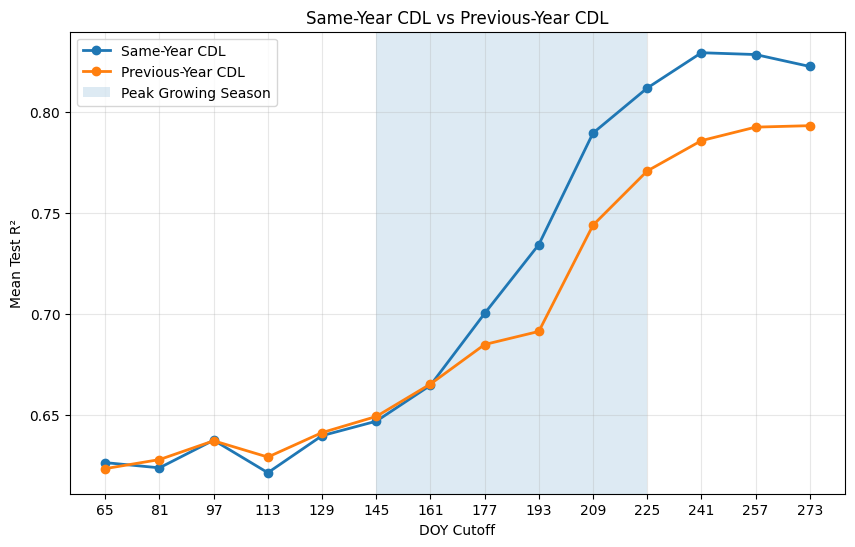

In [20]:
# ============================================================
# PLOT SAME-YEAR VS PREVIOUS-YEAR CDL
# ============================================================



plt.figure(figsize=(10, 6))

plt.plot(
    comparison_df["DOY"],
    comparison_df["Same_Year_CDL"],
    marker="o",
    linewidth=2,
    label="Same-Year CDL"
)

plt.plot(
    comparison_df["DOY"],
    comparison_df["Previous_Year_CDL"],
    marker="o",
    linewidth=2,
    label="Previous-Year CDL"
)

plt.axvspan(
    145,
    225,
    alpha=0.15,
    label="Peak Growing Season"
)

plt.xlabel("DOY Cutoff")
plt.ylabel("Mean Test R²")
plt.title("Same-Year CDL vs Previous-Year CDL")
plt.xticks(comparison_df["DOY"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [21]:
# ============================================================
# FEATURE IMPORTANCE COMPARISON
# SAME-YEAR CDL VS PREVIOUS-YEAR CDL
# ============================================================



TEST_YEARS = list(range(2018, 2025))

importance_same = []
importance_prev = []

for doy_cut in range(65, 274, 16):

    print(f"\n===== DOY {doy_cut} =====")

    for yr in TEST_YEARS:

        # ====================================================
        # SAME-YEAR CDL
        # ====================================================
        train_same = df_same_cdl[df_same_cdl["year"] < yr].copy()
        test_same = df_same_cdl[df_same_cdl["year"] == yr].copy()

        X_train_same = build_features(train_same, doy_cut)
        X_test_same = build_features(test_same, doy_cut)

        if not X_train_same.empty and not X_test_same.empty:

            X_train_same["hist_5yr"] = train_same.loc[X_train_same.index, "hist_5yr"]
            X_test_same["hist_5yr"] = test_same.loc[X_test_same.index, "hist_5yr"]

            X_train_same["year"] = train_same.loc[X_train_same.index, "year"]
            X_test_same["year"] = test_same.loc[X_test_same.index, "year"]

            X_train_same = X_train_same.fillna(X_train_same.median())
            X_test_same = X_test_same.fillna(X_train_same.median())

            y_train_same = train_same.loc[X_train_same.index, "yield_filled"]

            model_same = XGBRegressor(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )

            model_same.fit(X_train_same, y_train_same)

            temp_same = pd.DataFrame({
                "feature": X_train_same.columns,
                "importance": model_same.feature_importances_,
                "DOY": doy_cut,
                "year": yr,
                "dataset": "Same-Year CDL"
            })

            importance_same.append(temp_same)

        # ====================================================
        # PREVIOUS-YEAR CDL
        # ====================================================
        train_prev = df_prev_cdl[df_prev_cdl["year"] < yr].copy()
        test_prev = df_prev_cdl[df_prev_cdl["year"] == yr].copy()

        X_train_prev = build_features(train_prev, doy_cut)
        X_test_prev = build_features(test_prev, doy_cut)

        if not X_train_prev.empty and not X_test_prev.empty:

            X_train_prev["hist_5yr"] = train_prev.loc[X_train_prev.index, "hist_5yr"]
            X_test_prev["hist_5yr"] = test_prev.loc[X_test_prev.index, "hist_5yr"]

            X_train_prev["year"] = train_prev.loc[X_train_prev.index, "year"]
            X_test_prev["year"] = test_prev.loc[X_test_prev.index, "year"]

            X_train_prev = X_train_prev.fillna(X_train_prev.median())
            X_test_prev = X_test_prev.fillna(X_train_prev.median())

            y_train_prev = train_prev.loc[X_train_prev.index, "yield_filled"]

            model_prev = XGBRegressor(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            )

            model_prev.fit(X_train_prev, y_train_prev)

            temp_prev = pd.DataFrame({
                "feature": X_train_prev.columns,
                "importance": model_prev.feature_importances_,
                "DOY": doy_cut,
                "year": yr,
                "dataset": "Previous-Year CDL"
            })

            importance_prev.append(temp_prev)

importance_compare_df = pd.concat(
    importance_same + importance_prev,
    ignore_index=True
)

print("Done building feature importance table")
display(importance_compare_df.head())


===== DOY 65 =====



===== DOY 81 =====

===== DOY 97 =====

===== DOY 113 =====

===== DOY 129 =====

===== DOY 145 =====

===== DOY 161 =====

===== DOY 177 =====

===== DOY 193 =====

===== DOY 209 =====

===== DOY 225 =====

===== DOY 241 =====

===== DOY 257 =====

===== DOY 273 =====
Done building feature importance table


,feature,importance,DOY,year,dataset
0,EVI_scaled_mean,0.018225,65,2018,Same-Year CDL
1,EVI_scaled_max,0.027211,65,2018,Same-Year CDL
2,EVI_scaled_std,0.000000,65,2018,Same-Year CDL
3,EVI_scaled_last,0.012963,65,2018,Same-Year CDL
4,EVI_scaled_auc,0.000000,65,2018,Same-Year CDL


In [22]:
# ============================================================
# TOP FEATURES AT FINAL DOY
# ============================================================

final_doy = importance_compare_df["DOY"].max()

top_compare = (
    importance_compare_df[importance_compare_df["DOY"] == final_doy]
    .groupby(["dataset", "feature"])["importance"]
    .mean()
    .reset_index()
)

top_same = (
    top_compare[top_compare["dataset"] == "Same-Year CDL"]
    .sort_values("importance", ascending=False)
    .head(10)
)

top_prev = (
    top_compare[top_compare["dataset"] == "Previous-Year CDL"]
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nTop Same-Year CDL Features:")
display(top_same)

print("\nTop Previous-Year CDL Features:")
display(top_prev)


Top Same-Year CDL Features:


,dataset,feature,importance
81,Same-Year CDL,EVI_scaled_max,0.337608
121,Same-Year CDL,NIRv_std,0.182151
97,Same-Year CDL,GCI_std,0.056796
85,Same-Year CDL,EVI_scaled_std,0.040958
69,Same-Year CDL,EVI2_max,0.040774
112,Same-Year CDL,NIRv_anom_mean,0.028892
122,Same-Year CDL,hist_5yr,0.028558
90,Same-Year CDL,GCI_auc,0.021803
76,Same-Year CDL,EVI_scaled_anom_mean,0.018779
64,Same-Year CDL,EVI2_anom_mean,0.016028



Top Previous-Year CDL Features:


,dataset,feature,importance
59,Previous-Year CDL,NIRv_std,0.319879
19,Previous-Year CDL,EVI_scaled_max,0.141234
7,Previous-Year CDL,EVI2_max,0.128028
60,Previous-Year CDL,hist_5yr,0.035718
35,Previous-Year CDL,GCI_std,0.031986
23,Previous-Year CDL,EVI_scaled_std,0.025186
50,Previous-Year CDL,NIRv_anom_mean,0.024491
61,Previous-Year CDL,year,0.022594
11,Previous-Year CDL,EVI2_std,0.014708
26,Previous-Year CDL,GCI_anom_mean,0.014593


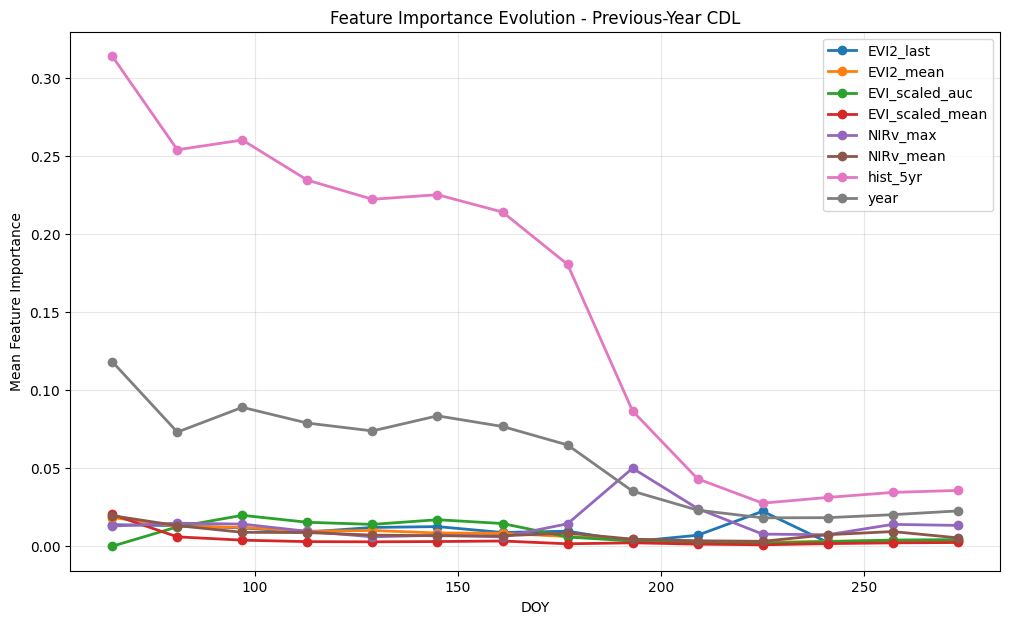

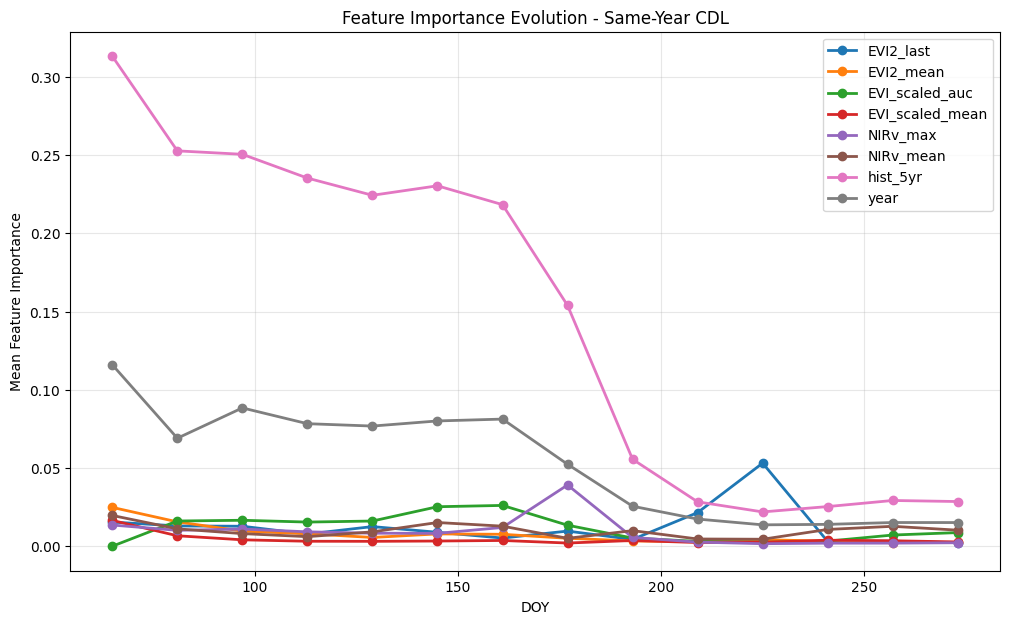

In [23]:
# ============================================================
# PLOT FEATURE IMPORTANCE EVOLUTION
# ============================================================


features_to_plot = [
    "hist_5yr",
    "year",
    "EVI2_mean",
    "EVI2_last",
    "NIRv_mean",
    "NIRv_max",
    "EVI_scaled_mean",
    "EVI_scaled_auc"
]

plot_df = (
    importance_compare_df[
        importance_compare_df["feature"].isin(features_to_plot)
    ]
    .groupby(["dataset", "DOY", "feature"])["importance"]
    .mean()
    .reset_index()
)

for dataset_name in plot_df["dataset"].unique():

    plt.figure(figsize=(12, 7))

    ds = plot_df[plot_df["dataset"] == dataset_name]

    for feat in ds["feature"].unique():

        feat_df = ds[ds["feature"] == feat]

        plt.plot(
            feat_df["DOY"],
            feat_df["importance"],
            marker="o",
            linewidth=2,
            label=feat
        )

    plt.xlabel("DOY")
    plt.ylabel("Mean Feature Importance")
    plt.title(f"Feature Importance Evolution - {dataset_name}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

Rolling anomaly importance dataframe created


,feature,importance,DOY,year
0,EVI_scaled_mean,0.016635,65,2018
1,EVI_scaled_max,0.015587,65,2018
2,EVI_scaled_std,0.000000,65,2018
3,EVI_scaled_last,0.022866,65,2018
4,EVI_scaled_auc,0.000000,65,2018


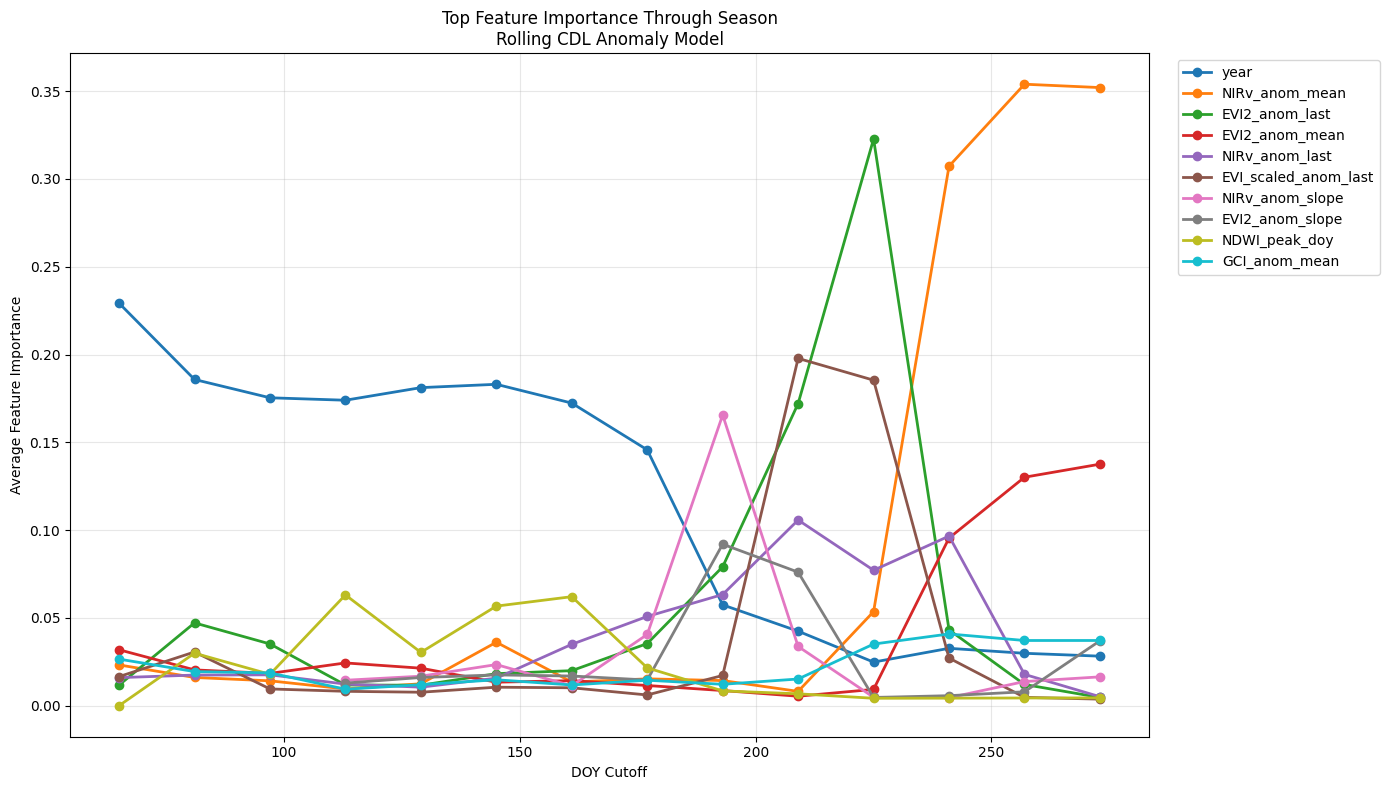

In [24]:
# ============================================================
# FEATURE IMPORTANCE FOR ROLLING CDL ANOMALY MODEL
# TRAIN SAME-YEAR CDL
# TEST PREVIOUS-YEAR CDL
# ============================================================

importance_rows = []

for doy_cut in range(65, 274, 16):

    for yr in TEST_YEARS:

        train_df = df_same_cdl[
            df_same_cdl["year"] < yr
        ].copy()

        test_df = df_prev_cdl[
            df_prev_cdl["year"] == yr
        ].copy()

        X_train = build_features(train_df, doy_cut)
        X_test = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        # ------------------------------------------------
        # REMOVE POSSIBLE LEAKAGE COLUMNS
        # ------------------------------------------------
        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(
            columns=[c for c in leakage_cols if c in X_train.columns],
            errors="ignore"
        )

        X_test = X_test.drop(
            columns=[c for c in leakage_cols if c in X_test.columns],
            errors="ignore"
        )

        # ------------------------------------------------
        # ADD SAFE FEATURES
        # ------------------------------------------------
        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"] = test_df.loc[X_test.index, "year"]

        # ------------------------------------------------
        # FILL MISSING VALUES
        # ------------------------------------------------
        train_medians = X_train.median()

        X_train = X_train.fillna(train_medians)
        X_test = X_test.fillna(train_medians)

        # ------------------------------------------------
        # TARGET = YIELD ANOMALY
        # ------------------------------------------------
        y_train = (
            train_df.loc[X_train.index, "yield_filled"] -
            train_df.loc[X_train.index, "hist_5yr"]
        )

        # ------------------------------------------------
        # MODEL
        # ------------------------------------------------
        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, y_train)

        temp_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.feature_importances_,
            "DOY": doy_cut,
            "year": yr
        })

        importance_rows.append(temp_df)

rolling_importance_df = pd.concat(importance_rows, ignore_index=True)

print("Rolling anomaly importance dataframe created")
display(rolling_importance_df.head())

# ============================================================
# AVERAGE FEATURE IMPORTANCE
# ============================================================

importance_summary = (
    rolling_importance_df
    .groupby(["DOY", "feature"])["importance"]
    .mean()
    .reset_index()
)

top_features = (
    importance_summary
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_df = importance_summary[
    importance_summary["feature"].isin(top_features)
]

# ============================================================
# PLOT
# ============================================================



plt.figure(figsize=(14, 8))

for feature in top_features:

    temp = plot_df[
        plot_df["feature"] == feature
    ].sort_values("DOY")

    plt.plot(
        temp["DOY"],
        temp["importance"],
        marker="o",
        linewidth=2,
        label=feature
    )

plt.xlabel("DOY Cutoff")
plt.ylabel("Average Feature Importance")
plt.title("Top Feature Importance Through Season\nRolling CDL Anomaly Model")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

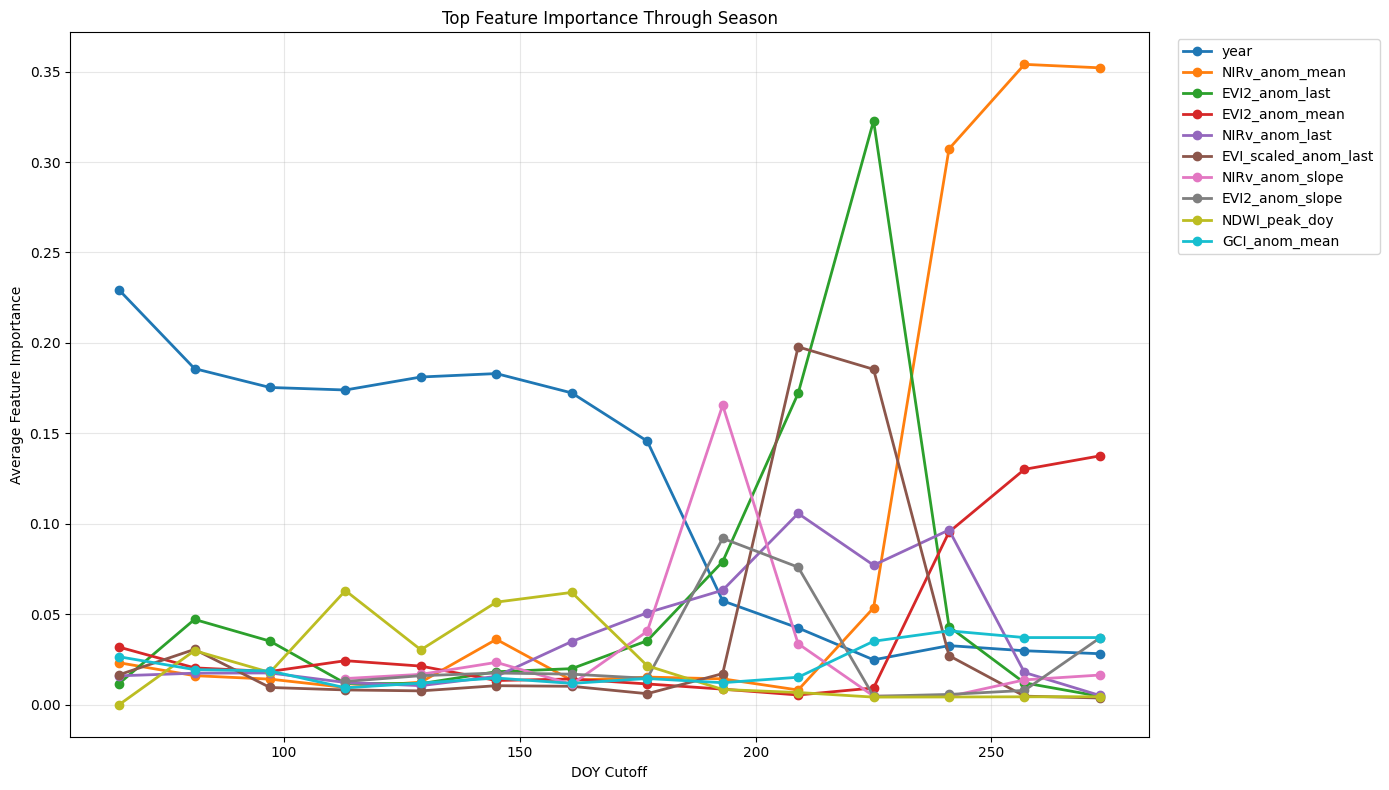

In [25]:
# ============================================================
# TOP FEATURE IMPORTANCE THROUGH THE SEASON
# ============================================================




# ------------------------------------------------
# Average feature importance across years
# ------------------------------------------------

avg_importance = (
    rolling_importance_df
    .groupby(["DOY", "feature"])["importance"]
    .mean()
    .reset_index()
)

# ------------------------------------------------
# Find top features overall
# ------------------------------------------------

top_features = (
    avg_importance
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_df = avg_importance[
    avg_importance["feature"].isin(top_features)
]

# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(14, 8))

for feature in top_features:

    temp = plot_df[
        plot_df["feature"] == feature
    ].sort_values("DOY")

    plt.plot(
        temp["DOY"],
        temp["importance"],
        marker="o",
        linewidth=2,
        label=feature
    )

plt.xlabel("DOY Cutoff")
plt.ylabel("Average Feature Importance")
plt.title("Top Feature Importance Through Season")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

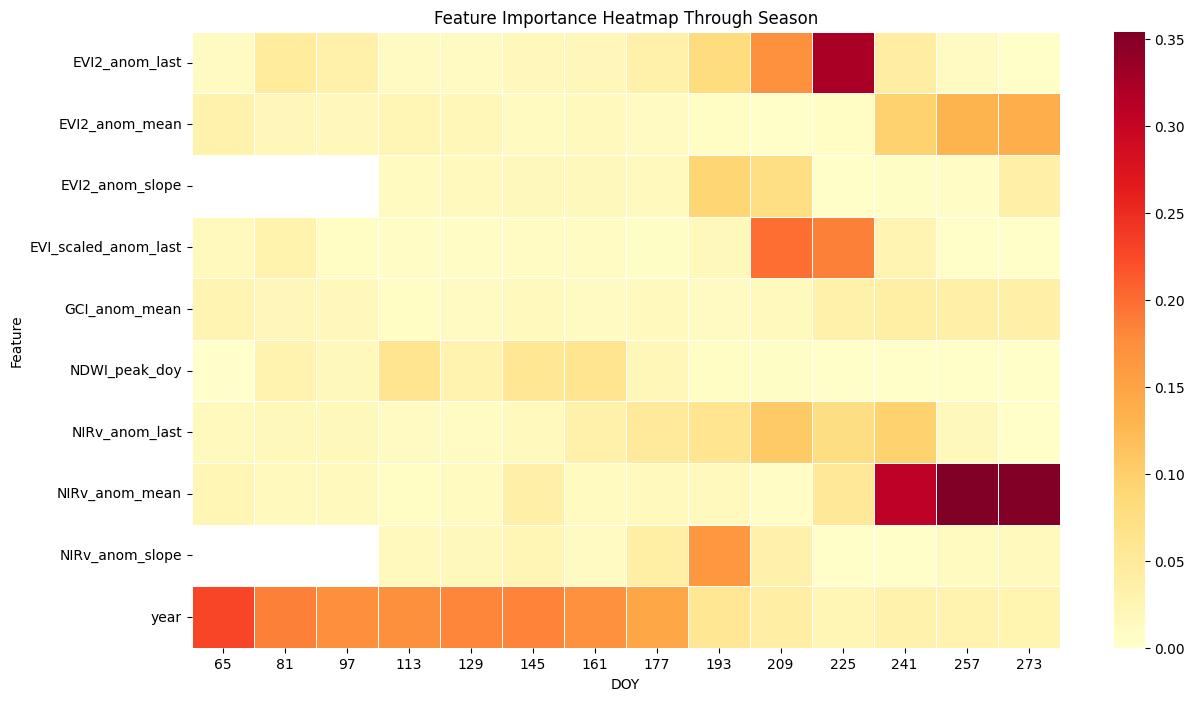

In [26]:
# ============================================================
# HEATMAP OF FEATURE IMPORTANCE
# ============================================================

heatmap_df = (
    avg_importance[
        avg_importance["feature"].isin(top_features)
    ]
    .pivot(
        index="feature",
        columns="DOY",
        values="importance"
    )
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_df,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Feature Importance Heatmap Through Season")
plt.xlabel("DOY")
plt.ylabel("Feature")
plt.show()

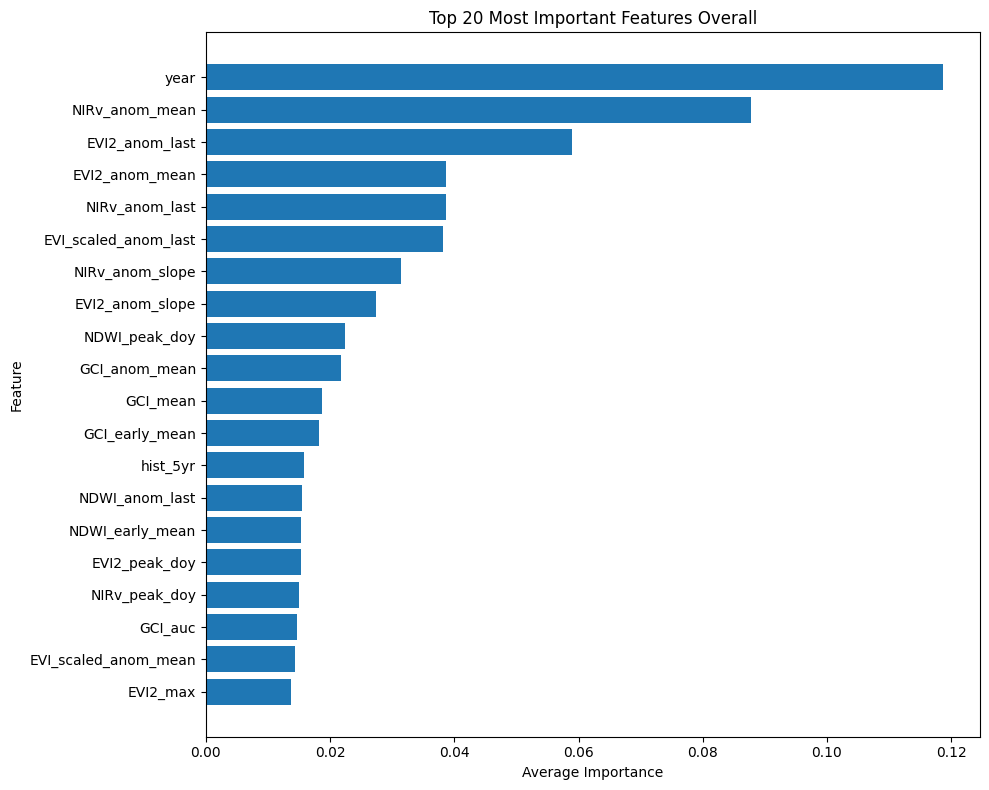

In [27]:
# ============================================================
# BAR CHART OF MOST IMPORTANT FEATURES OVERALL
# ============================================================

overall_importance = (
    rolling_importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

plt.figure(figsize=(10, 8))

plt.barh(
    overall_importance["feature"][::-1],
    overall_importance["importance"][::-1]
)

plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features Overall")
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# ROLLING CDL MODEL USING YIELD ANOMALY TARGET
# Train years use SAME-YEAR CDL
# Test year uses PREVIOUS-YEAR CDL
# ============================================================



TEST_YEARS = list(range(2018, 2025))

rolling_results = []

for doy_cut in range(65, 274, 16):

    print(f"\n===== DOY {doy_cut} =====")

    for yr in TEST_YEARS:

        # ------------------------------------------------
        # TRAIN: completed years use same-year CDL
        # ------------------------------------------------
        train_df = df_same_cdl[
            df_same_cdl["year"] < yr
        ].copy()

        # ------------------------------------------------
        # TEST: forecast year uses previous-year CDL
        # ------------------------------------------------
        test_df = df_prev_cdl[
            df_prev_cdl["year"] == yr
        ].copy()

        # ------------------------------------------------
        # BUILD FEATURES
        # ------------------------------------------------
        X_train = build_features(train_df, doy_cut)
        X_test = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        # ------------------------------------------------
        # REMOVE POSSIBLE LEAKAGE COLUMNS
        # ------------------------------------------------
        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(
            columns=[c for c in leakage_cols if c in X_train.columns],
            errors="ignore"
        )

        X_test = X_test.drop(
            columns=[c for c in leakage_cols if c in X_test.columns],
            errors="ignore"
        )

        # ------------------------------------------------
        # ADD SAFE FEATURES
        # ------------------------------------------------
        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"] = test_df.loc[X_test.index, "year"]

        # ------------------------------------------------
        # FILL MISSING VALUES USING TRAIN MEDIANS
        # ------------------------------------------------
        train_medians = X_train.median()

        X_train = X_train.fillna(train_medians)
        X_test = X_test.fillna(train_medians)

        # ------------------------------------------------
        # BUILD ANOMALY TARGETS
        # ------------------------------------------------
        train_target = (
            train_df.loc[X_train.index, "yield_filled"] -
            train_df.loc[X_train.index, "hist_5yr"]
        )

        test_target = (
            test_df.loc[X_test.index, "yield_bu_acre"] -
            test_df.loc[X_test.index, "hist_5yr"]
        )

        # ------------------------------------------------
        # MODEL
        # ------------------------------------------------
        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, train_target)

        pred_anomaly = model.predict(X_test)

        # ------------------------------------------------
        # CONVERT BACK TO FINAL YIELD PREDICTIONS
        # ------------------------------------------------
        pred_yield = (
            test_df.loc[X_test.index, "hist_5yr"].values +
            pred_anomaly
        )

        actual_yield = test_df.loc[X_test.index, "yield_bu_acre"].values

        r2 = r2_score(actual_yield, pred_yield)
        rmse = np.sqrt(mean_squared_error(actual_yield, pred_yield))

        rolling_results.append({
            "year": yr,
            "DOY": doy_cut,
            "R2": r2,
            "RMSE": rmse
        })

        print(f"Year {yr} | DOY {doy_cut} | R² = {r2:.3f} | RMSE = {rmse:.2f}")

rolling_results_df = pd.DataFrame(rolling_results)

summary_df = (
    rolling_results_df
    .groupby("DOY")[["R2", "RMSE"]]
    .mean()
    .reset_index()
)

print("\n===== FINAL SUMMARY =====")
display(summary_df)


===== DOY 65 =====
Year 2018 | DOY 65 | R² = 0.661 | RMSE = 21.11
Year 2019 | DOY 65 | R² = 0.518 | RMSE = 20.03
Year 2020 | DOY 65 | R² = 0.549 | RMSE = 21.07
Year 2021 | DOY 65 | R² = 0.617 | RMSE = 25.23
Year 2022 | DOY 65 | R² = 0.641 | RMSE = 24.94
Year 2023 | DOY 65 | R² = 0.722 | RMSE = 19.57
Year 2024 | DOY 65 | R² = 0.638 | RMSE = 21.39

===== DOY 81 =====
Year 2018 | DOY 81 | R² = 0.651 | RMSE = 21.42
Year 2019 | DOY 81 | R² = 0.487 | RMSE = 20.67
Year 2020 | DOY 81 | R² = 0.601 | RMSE = 19.83
Year 2021 | DOY 81 | R² = 0.657 | RMSE = 23.87
Year 2022 | DOY 81 | R² = 0.629 | RMSE = 25.36
Year 2023 | DOY 81 | R² = 0.703 | RMSE = 20.21
Year 2024 | DOY 81 | R² = 0.660 | RMSE = 20.73

===== DOY 97 =====
Year 2018 | DOY 97 | R² = 0.628 | RMSE = 22.13
Year 2019 | DOY 97 | R² = 0.586 | RMSE = 18.56
Year 2020 | DOY 97 | R² = 0.592 | RMSE = 20.03
Year 2021 | DOY 97 | R² = 0.669 | RMSE = 23.44
Year 2022 | DOY 97 | R² = 0.648 | RMSE = 24.68
Year 2023 | DOY 97 | R² = 0.701 | RMSE = 20.30


,DOY,R2,RMSE
0,65,0.620810,21.906335
1,81,0.626817,21.726329
2,97,0.640554,21.413366
3,113,0.622919,21.881931
4,129,0.638998,21.349787
5,145,0.649348,21.096544
6,161,0.674011,20.472979
7,177,0.680494,20.074911
8,193,0.657142,20.426252
9,209,0.707749,18.697028


In [29]:
rolling_results_anomaly_df = rolling_results_df.copy()

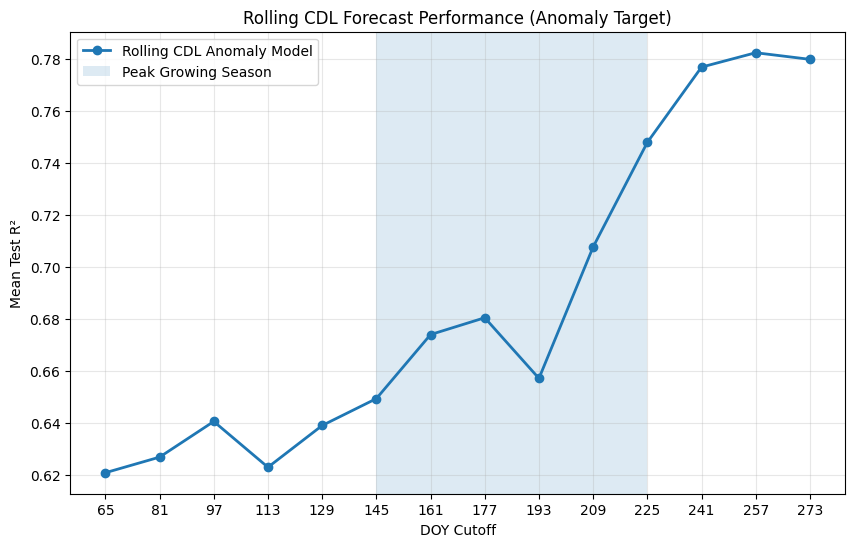

In [30]:
# ============================================================
# PLOT ANOMALY MODEL RESULTS
# ============================================================


plt.figure(figsize=(10, 6))

plt.plot(
    summary_df["DOY"],
    summary_df["R2"],
    marker="o",
    linewidth=2,
    label="Rolling CDL Anomaly Model"
)

plt.axvspan(145, 225, alpha=0.15, label="Peak Growing Season")

plt.xlabel("DOY Cutoff")
plt.ylabel("Mean Test R²")
plt.title("Rolling CDL Forecast Performance (Anomaly Target)")
plt.xticks(summary_df["DOY"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

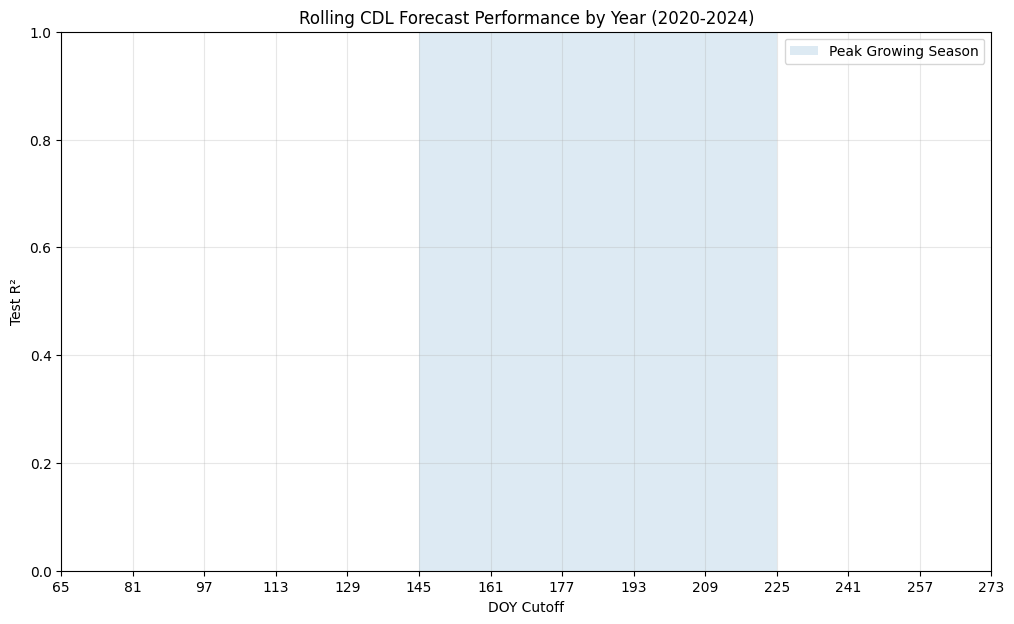

In [31]:
# ============================================================
# PLOT YEAR-BY-YEAR RESULTS FROM 2020-2024
# Uses rolling_results_df from your anomaly model
# ============================================================



plot_years = [2020, 2021, 2022, 2023, 2024]

plt.figure(figsize=(12, 7))



plt.axvspan(145, 225, alpha=0.15, label="Peak Growing Season")

plt.xlabel("DOY Cutoff")
plt.ylabel("Test R²")
plt.title("Rolling CDL Forecast Performance by Year (2020-2024)")
plt.xticks(sorted(rolling_results_df["DOY"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

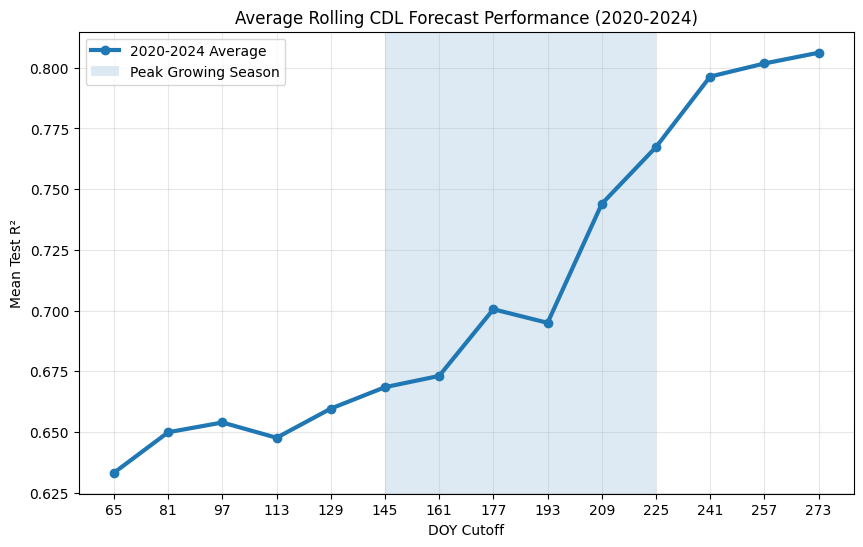


Average R² values from 2020-2024:


,DOY,R2
0,65,0.633273
1,81,0.649939
2,97,0.653955
3,113,0.647665
4,129,0.659670
5,145,0.668497
6,161,0.673126
7,177,0.700584
8,193,0.694987
9,209,0.743971


In [32]:
# ============================================================
# AVERAGE PERFORMANCE CURVE FOR 2020-2024
# ============================================================



avg_2020_2024 = (
    rolling_results_df[
        rolling_results_df["year"].between(2020, 2024)
    ]
    .groupby("DOY")["R2"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.plot(
    avg_2020_2024["DOY"],
    avg_2020_2024["R2"],
    marker="o",
    linewidth=3,
    label="2020-2024 Average"
)

plt.axvspan(145, 225, alpha=0.15, label="Peak Growing Season")

plt.xlabel("DOY Cutoff")
plt.ylabel("Mean Test R²")
plt.title("Average Rolling CDL Forecast Performance (2020-2024)")
plt.xticks(avg_2020_2024["DOY"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("\nAverage R² values from 2020-2024:")
display(avg_2020_2024)

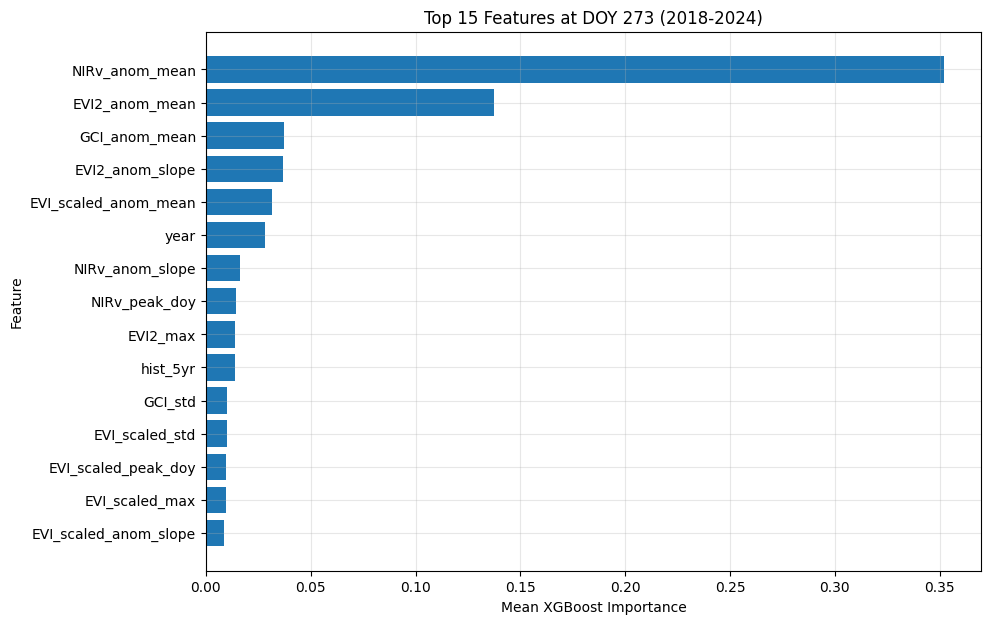

,feature,importance
50,NIRv_anom_mean,0.352073
2,EVI2_anom_mean,0.137556
26,GCI_anom_mean,0.037119
3,EVI2_anom_slope,0.036940
14,EVI_scaled_anom_mean,0.031762
61,year,0.028194
51,NIRv_anom_slope,0.016398
57,NIRv_peak_doy,0.014513
7,EVI2_max,0.013665
60,hist_5yr,0.013647


In [33]:
# ============================================================
# FEATURE IMPORTANCE FOR 2018-2024
# Uses rolling CDL anomaly model setup
# ============================================================



importance_rows = []

for doy_cut in range(65, 274, 16):

    for yr in range(2018, 2025):

        train_df = df_same_cdl[
            df_same_cdl["year"] < yr
        ].copy()

        test_df = df_prev_cdl[
            df_prev_cdl["year"] == yr
        ].copy()

        X_train = build_features(train_df, doy_cut)
        X_test = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(
            columns=[c for c in leakage_cols if c in X_train.columns],
            errors="ignore"
        )

        X_test = X_test.drop(
            columns=[c for c in leakage_cols if c in X_test.columns],
            errors="ignore"
        )

        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"] = test_df.loc[X_test.index, "year"]

        train_medians = X_train.median()
        X_train = X_train.fillna(train_medians)
        X_test = X_test.fillna(train_medians)

        train_target = (
            train_df.loc[X_train.index, "yield_filled"] -
            train_df.loc[X_train.index, "hist_5yr"]
        )

        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, train_target)

        temp_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.feature_importances_,
            "DOY": doy_cut,
            "year": yr
        })

        importance_rows.append(temp_df)

importance_2018_2024_df = pd.concat(importance_rows, ignore_index=True)

final_doy = importance_2018_2024_df["DOY"].max()

top_feats_2018_2024 = (
    importance_2018_2024_df[
        importance_2018_2024_df["DOY"] == final_doy
    ]
    .groupby("feature")["importance"]
    .mean()
    .reset_index()
    .sort_values("importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_feats_2018_2024["feature"][::-1],
    top_feats_2018_2024["importance"][::-1]
)
plt.xlabel("Mean XGBoost Importance")
plt.ylabel("Feature")
plt.title(f"Top 15 Features at DOY {final_doy} (2018-2024)")
plt.grid(True, alpha=0.3)
plt.show()

display(top_feats_2018_2024)

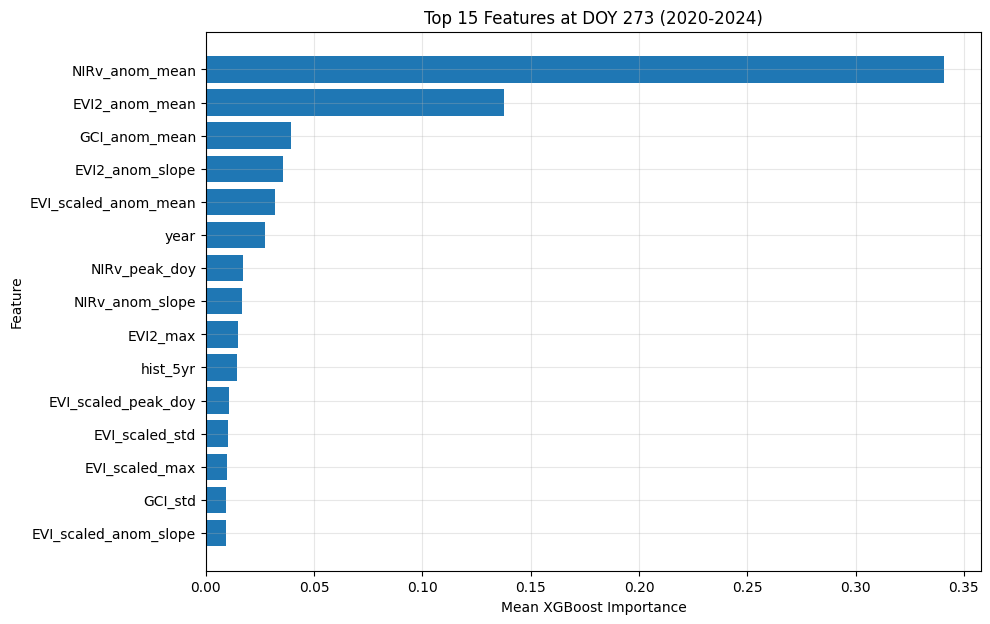

,feature,importance
50,NIRv_anom_mean,0.340855
2,EVI2_anom_mean,0.137806
26,GCI_anom_mean,0.039069
3,EVI2_anom_slope,0.035420
14,EVI_scaled_anom_mean,0.031908
61,year,0.027302
57,NIRv_peak_doy,0.017301
51,NIRv_anom_slope,0.016730
7,EVI2_max,0.014736
60,hist_5yr,0.014429


In [34]:
# ============================================================
# FEATURE IMPORTANCE FOR 2020-2024 ONLY
# ============================================================

importance_rows = []

for doy_cut in range(65, 274, 16):

    for yr in range(2020, 2025):

        train_df = df_same_cdl[
            df_same_cdl["year"] < yr
        ].copy()

        test_df = df_prev_cdl[
            df_prev_cdl["year"] == yr
        ].copy()

        X_train = build_features(train_df, doy_cut)
        X_test = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(
            columns=[c for c in leakage_cols if c in X_train.columns],
            errors="ignore"
        )

        X_test = X_test.drop(
            columns=[c for c in leakage_cols if c in X_test.columns],
            errors="ignore"
        )

        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"] = test_df.loc[X_test.index, "year"]

        train_medians = X_train.median()
        X_train = X_train.fillna(train_medians)
        X_test = X_test.fillna(train_medians)

        train_target = (
            train_df.loc[X_train.index, "yield_filled"] -
            train_df.loc[X_train.index, "hist_5yr"]
        )

        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, train_target)

        temp_df = pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.feature_importances_,
            "DOY": doy_cut,
            "year": yr
        })

        importance_rows.append(temp_df)

importance_2020_2024_df = pd.concat(importance_rows, ignore_index=True)

final_doy = importance_2020_2024_df["DOY"].max()

top_feats_2020_2024 = (
    importance_2020_2024_df[
        importance_2020_2024_df["DOY"] == final_doy
    ]
    .groupby("feature")["importance"]
    .mean()
    .reset_index()
    .sort_values("importance", ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_feats_2020_2024["feature"][::-1],
    top_feats_2020_2024["importance"][::-1]
)
plt.xlabel("Mean XGBoost Importance")
plt.ylabel("Feature")
plt.title(f"Top 15 Features at DOY {final_doy} (2020-2024)")
plt.grid(True, alpha=0.3)
plt.show()

display(top_feats_2020_2024)

In [35]:
# ============================================================
# MULTI-MODEL COMPARISON
# Rolling CDL + Anomaly Target
# Models:
# - XGBoost
# - Random Forest
# - CatBoost
# - SVR
# ============================================================



TEST_YEARS = list(range(2020, 2025))

results = []

for doy_cut in range(65, 274, 16):

    print(f"\n===== DOY {doy_cut} =====")

    for yr in TEST_YEARS:

        # ------------------------------------------------
        # TRAIN / TEST SPLIT
        # ------------------------------------------------
        train_df = df_same_cdl[
            df_same_cdl["year"] < yr
        ].copy()

        test_df = df_prev_cdl[
            df_prev_cdl["year"] == yr
        ].copy()

        X_train = build_features(train_df, doy_cut)
        X_test = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        # ------------------------------------------------
        # REMOVE LEAKAGE COLUMNS
        # ------------------------------------------------
        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(
            columns=[c for c in leakage_cols if c in X_train.columns],
            errors="ignore"
        )

        X_test = X_test.drop(
            columns=[c for c in leakage_cols if c in X_test.columns],
            errors="ignore"
        )

        # ------------------------------------------------
        # ADD SAFE FEATURES
        # ------------------------------------------------
        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"] = test_df.loc[X_test.index, "year"]

        # ------------------------------------------------
        # FILL MISSING VALUES USING TRAIN MEDIANS
        # ------------------------------------------------
        train_medians = X_train.median()

        X_train = X_train.fillna(train_medians)
        X_test = X_test.fillna(train_medians)

        # ------------------------------------------------
        # ANOMALY TARGET
        # ------------------------------------------------
        y_train = (
            train_df.loc[X_train.index, "yield_filled"] -
            train_df.loc[X_train.index, "hist_5yr"]
        )

        y_test_actual = test_df.loc[X_test.index, "yield_bu_acre"].values

        # ------------------------------------------------
        # DEFINE MODELS
        # ------------------------------------------------
        models = {
            "XGBoost": XGBRegressor(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42
            ),

            "RandomForest": RandomForestRegressor(
                n_estimators=400,
                max_depth=12,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            ),

            "CatBoost": CatBoostRegressor(
                iterations=400,
                depth=6,
                learning_rate=0.05,
                loss_function="RMSE",
                verbose=0,
                random_state=42
            ),

            "SVR": Pipeline([
                ("scaler", StandardScaler()),
                ("svr", SVR(
                    kernel="rbf",
                    C=15,
                    epsilon=0.05,
                    gamma="scale"
                ))
            ])
        }

        # ------------------------------------------------
        # RUN ALL MODELS
        # ------------------------------------------------
        for model_name, model in models.items():

            model.fit(X_train, y_train)

            pred_anomaly = model.predict(X_test)

            pred_yield = (
                test_df.loc[X_test.index, "hist_5yr"].values +
                pred_anomaly
            )

            r2 = r2_score(y_test_actual, pred_yield)
            rmse = np.sqrt(mean_squared_error(y_test_actual, pred_yield))

            results.append({
                "year": yr,
                "DOY": doy_cut,
                "model": model_name,
                "R2": r2,
                "RMSE": rmse
            })

            print(
                f"{model_name} | Year {yr} | "
                f"DOY {doy_cut} | R² = {r2:.3f}"
            )

results_df = pd.DataFrame(results)

summary_df = (
    results_df
    .groupby(["DOY", "model"])[["R2", "RMSE"]]
    .mean()
    .reset_index()
)

print("\n===== FINAL SUMMARY =====")
display(summary_df)


===== DOY 65 =====
XGBoost | Year 2020 | DOY 65 | R² = 0.549
RandomForest | Year 2020 | DOY 65 | R² = 0.501
CatBoost | Year 2020 | DOY 65 | R² = 0.578
SVR | Year 2020 | DOY 65 | R² = 0.330
XGBoost | Year 2021 | DOY 65 | R² = 0.617
RandomForest | Year 2021 | DOY 65 | R² = 0.623
CatBoost | Year 2021 | DOY 65 | R² = 0.637
SVR | Year 2021 | DOY 65 | R² = 0.508
XGBoost | Year 2022 | DOY 65 | R² = 0.641
RandomForest | Year 2022 | DOY 65 | R² = 0.629
CatBoost | Year 2022 | DOY 65 | R² = 0.643
SVR | Year 2022 | DOY 65 | R² = 0.623
XGBoost | Year 2023 | DOY 65 | R² = 0.722
RandomForest | Year 2023 | DOY 65 | R² = 0.713
CatBoost | Year 2023 | DOY 65 | R² = 0.711
SVR | Year 2023 | DOY 65 | R² = 0.683
XGBoost | Year 2024 | DOY 65 | R² = 0.638
RandomForest | Year 2024 | DOY 65 | R² = 0.615
CatBoost | Year 2024 | DOY 65 | R² = 0.651
SVR | Year 2024 | DOY 65 | R² = 0.639

===== DOY 81 =====
XGBoost | Year 2020 | DOY 81 | R² = 0.601
RandomForest | Year 2020 | DOY 81 | R² = 0.560
CatBoost | Year 2020 

,DOY,model,R2,RMSE
0,65,CatBoost,0.644001,22.150424
1,65,RandomForest,0.616245,22.893894
2,65,SVR,0.556488,24.418050
3,65,XGBoost,0.633273,22.440559
4,81,CatBoost,0.663071,21.564062
5,81,RandomForest,0.642282,22.175141
6,81,SVR,0.598946,23.377441
7,81,XGBoost,0.649939,21.998900
8,97,CatBoost,0.660116,21.626027
9,97,RandomForest,0.635151,22.423319


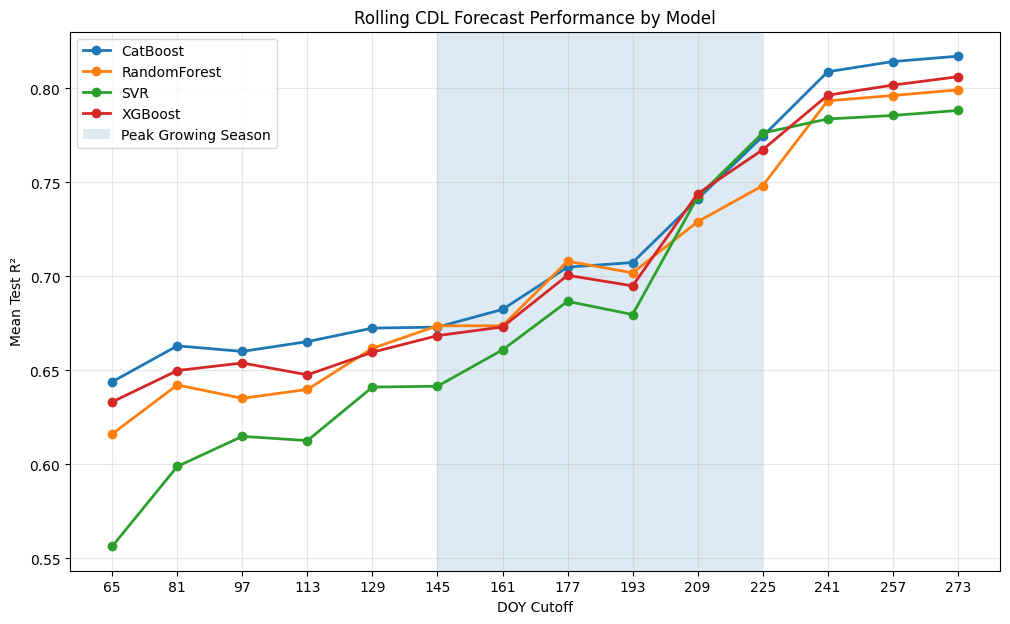

In [36]:
# ============================================================
# PLOT MULTI-MODEL COMPARISON
# ============================================================



plt.figure(figsize=(12, 7))

for model_name in summary_df["model"].unique():

    temp = summary_df[
        summary_df["model"] == model_name
    ]

    plt.plot(
        temp["DOY"],
        temp["R2"],
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.axvspan(145, 225, alpha=0.15, label="Peak Growing Season")

plt.xlabel("DOY Cutoff")
plt.ylabel("Mean Test R²")
plt.title("Rolling CDL Forecast Performance by Model")
plt.xticks(sorted(summary_df["DOY"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Best overall model: CatBoost

===== DOY 60 =====

===== DOY 76 =====

===== DOY 92 =====

===== DOY 108 =====

===== DOY 124 =====

===== DOY 140 =====

===== DOY 156 =====

===== DOY 172 =====

===== DOY 188 =====

===== DOY 204 =====

===== DOY 220 =====

===== DOY 236 =====

===== DOY 252 =====

===== DOY 268 =====


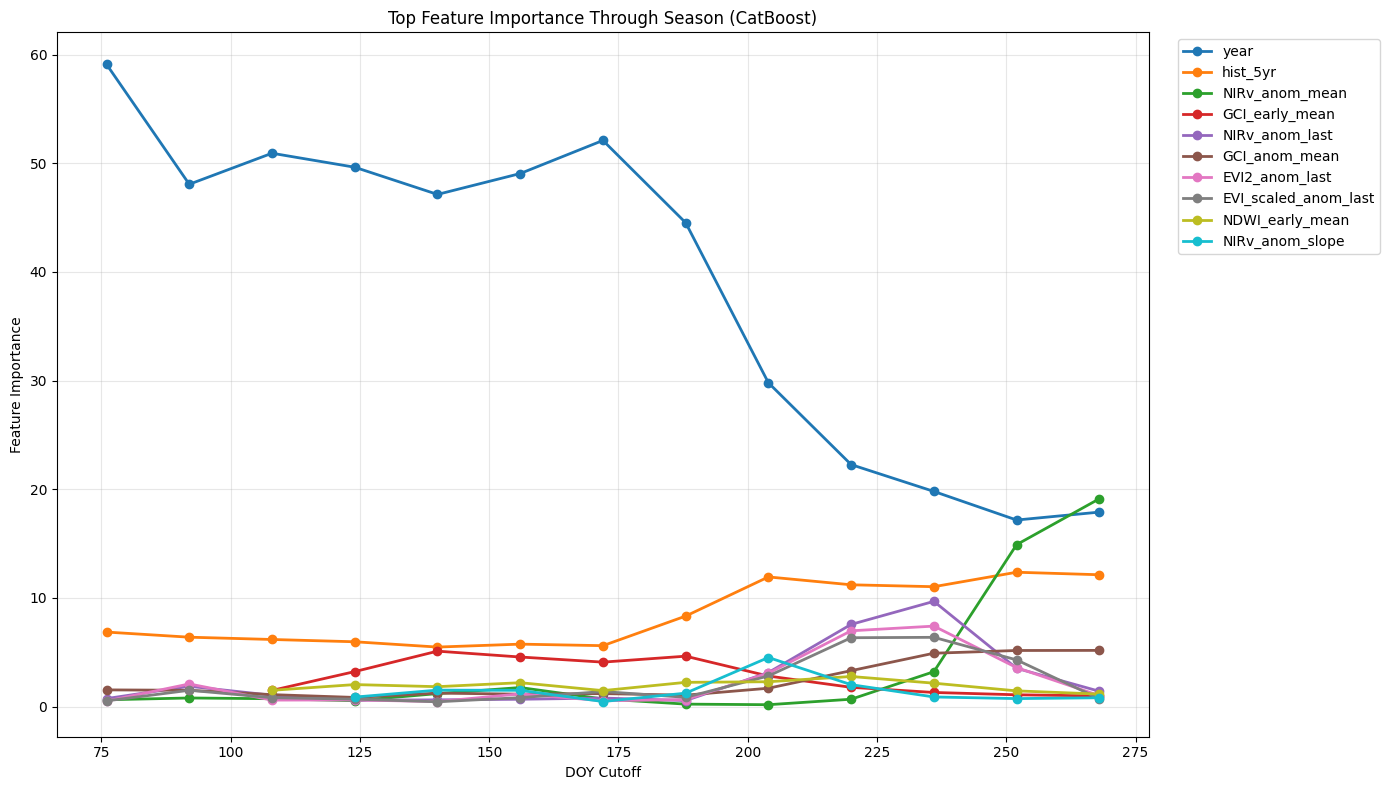


Average Feature Importance Across Entire Season


,feature,importance
0,year,39.036515
1,hist_5yr,8.405752
2,NIRv_anom_mean,3.440040
3,GCI_early_mean,2.828274
4,NIRv_anom_last,2.481223
5,GCI_anom_mean,2.301759
6,EVI2_anom_last,2.210767
7,EVI_scaled_anom_last,2.127259
8,NDWI_early_mean,1.920395
9,NIRv_anom_slope,1.461188


In [37]:
# ============================================================
# FEATURE IMPORTANCE OF BEST PERFORMING MODEL THROUGHOUT YEAR
# Uses the best average model from summary_df
# ============================================================





# ------------------------------------------------
# STEP 1: Find best model overall
# ------------------------------------------------

best_model_name = (
    results_df
    .groupby("model")["R2"]
    .mean()
    .idxmax()
)

print("Best overall model:", best_model_name)

# ------------------------------------------------
# STEP 2: Define feature importance storage
# ------------------------------------------------

importance_results = []

# ------------------------------------------------
# STEP 3: Loop through DOYs
# ------------------------------------------------

for doy_cut in range(60, 275, 16):

    print(f"\n===== DOY {doy_cut} =====")

    # ------------------------------------------------
    # Use all training years before 2024
    # and test on 2024 just to keep setup consistent
    # ------------------------------------------------

    train_df = df_same_cdl[
        df_same_cdl["year"] < 2024
    ].copy()

    X_train = build_features(train_df, doy_cut)

    if X_train.empty:
        continue

    # ------------------------------------------------
    # Remove leakage columns
    # ------------------------------------------------

    leakage_cols = [
        "yield_bu_acre",
        "yield_filled",
        "yield_anomaly",
        "target",
        "yield"
    ]

    X_train = X_train.drop(
        columns=[c for c in leakage_cols if c in X_train.columns],
        errors="ignore"
    )

    # ------------------------------------------------
    # Add safe features
    # ------------------------------------------------

    X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
    X_train["year"] = train_df.loc[X_train.index, "year"]

    # ------------------------------------------------
    # Fill missing values
    # ------------------------------------------------

    train_medians = X_train.median()
    X_train = X_train.fillna(train_medians)

    # ------------------------------------------------
    # Target = anomaly
    # ------------------------------------------------

    y_train = (
        train_df.loc[X_train.index, "yield_filled"] -
        train_df.loc[X_train.index, "hist_5yr"]
    )

    # ------------------------------------------------
    # Build best model
    # ------------------------------------------------

    if best_model_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

    elif best_model_name == "RandomForest":
        model = RandomForestRegressor(
            n_estimators=400,
            max_depth=12,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        )

    elif best_model_name == "CatBoost":
        model = CatBoostRegressor(
            iterations=400,
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            verbose=0,
            random_state=42
        )

    else:
        print("Feature importance not available for SVR")
        break

    # ------------------------------------------------
    # Fit model
    # ------------------------------------------------

    model.fit(X_train, y_train)

    # ------------------------------------------------
    # Extract feature importances
    # ------------------------------------------------

    if best_model_name == "CatBoost":
        importances = model.get_feature_importance()
    else:
        importances = model.feature_importances_

    temp_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": importances,
        "DOY": doy_cut
    })

    importance_results.append(temp_df)

# ------------------------------------------------
# STEP 4: Combine all DOY results
# ------------------------------------------------

importance_df = pd.concat(importance_results, ignore_index=True)

# ------------------------------------------------
# STEP 5: Keep top features overall
# ------------------------------------------------

top_features = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plot_df = importance_df[
    importance_df["feature"].isin(top_features)
]

# ------------------------------------------------
# STEP 6: Plot feature importance through season
# ------------------------------------------------

plt.figure(figsize=(14, 8))

for feature in top_features:

    temp = plot_df[
        plot_df["feature"] == feature
    ].sort_values("DOY")

    plt.plot(
        temp["DOY"],
        temp["importance"],
        marker="o",
        linewidth=2,
        label=feature
    )

plt.xlabel("DOY Cutoff")
plt.ylabel("Feature Importance")
plt.title(f"Top Feature Importance Through Season ({best_model_name})")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# STEP 7: Optional table of most important features
# ------------------------------------------------

feature_summary = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\nAverage Feature Importance Across Entire Season")
display(feature_summary.head(20))


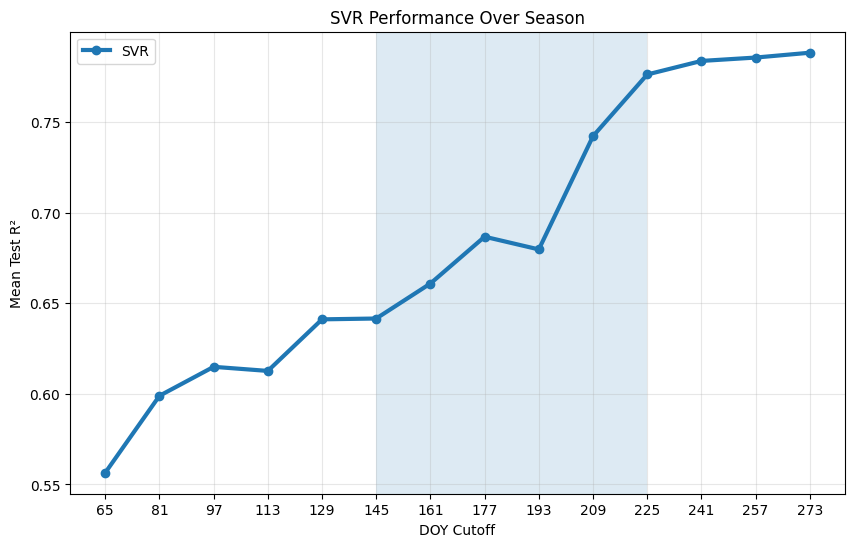

In [38]:
# ============================================================
# OPTIONAL: PLOT SVR ONLY
# ============================================================

svr_df = summary_df[
    summary_df["model"] == "SVR"
]

plt.figure(figsize=(10, 6))

plt.plot(
    svr_df["DOY"],
    svr_df["R2"],
    marker="o",
    linewidth=3,
    label="SVR"
)

plt.axvspan(145, 225, alpha=0.15)

plt.xlabel("DOY Cutoff")
plt.ylabel("Mean Test R²")
plt.title("SVR Performance Over Season")
plt.xticks(svr_df["DOY"])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [39]:
# ============================================================
# CELL 1: DOWNLOAD TIGER COUNTY SHAPEFILE
# ============================================================



tiger_url = "https://www2.census.gov/geo/tiger/TIGER2018/COUNTY/tl_2018_us_county.zip"

county_shapes = gpd.read_file(tiger_url)

print("County rows:", len(county_shapes))
print(county_shapes.columns.tolist())

County rows: 3233
['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']


In [40]:
# ============================================================
# CELL 2: BUILD FIPS COLUMN
# ============================================================

county_shapes["FIPS"] = (
    county_shapes["STATEFP"].astype(str) +
    county_shapes["COUNTYFP"].astype(str)
)

county_shapes["FIPS"] = county_shapes["FIPS"].str.zfill(5)

print(county_shapes[["STATEFP", "COUNTYFP", "FIPS", "NAME"]].head())

  STATEFP COUNTYFP   FIPS       NAME
0      31      039  31039     Cuming
1      53      069  53069  Wahkiakum
2      35      011  35011    De Baca
3      31      109  31109  Lancaster
4      31      129  31129   Nuckolls


In [41]:
# ============================================================
# CELL 3: KEEP ONLY CORN BELT STATES
# ============================================================

corn_belt_states = [
    "19",  # Iowa
    "17",  # Illinois
    "18",  # Indiana
    "31",  # Nebraska
    "27",  # Minnesota
    "29",  # Missouri
    "20",  # Kansas
    "46",  # South Dakota
    "38",  # North Dakota
    "39",  # Ohio
    "55",  # Wisconsin
    "26"   # Michigan
]

county_shapes = county_shapes[
    county_shapes["STATEFP"].isin(corn_belt_states)
].copy()

print("Filtered county rows:", len(county_shapes))
print(county_shapes["STATEFP"].value_counts().sort_index())

Filtered county rows: 1055
STATEFP
17    102
18     92
19     99
20    105
26     83
27     87
29    115
31     93
38     53
39     88
46     66
55     72
Name: count, dtype: int64


Using county ID column: GEOID
Running DOY 60
Skipping DOY 60 because features are empty
Running DOY 76
Running DOY 92
Running DOY 108
Running DOY 124
Running DOY 140
Running DOY 156
Running DOY 172
Running DOY 188
Running DOY 204
Running DOY 220
Running DOY 236
Running DOY 252
Running DOY 268


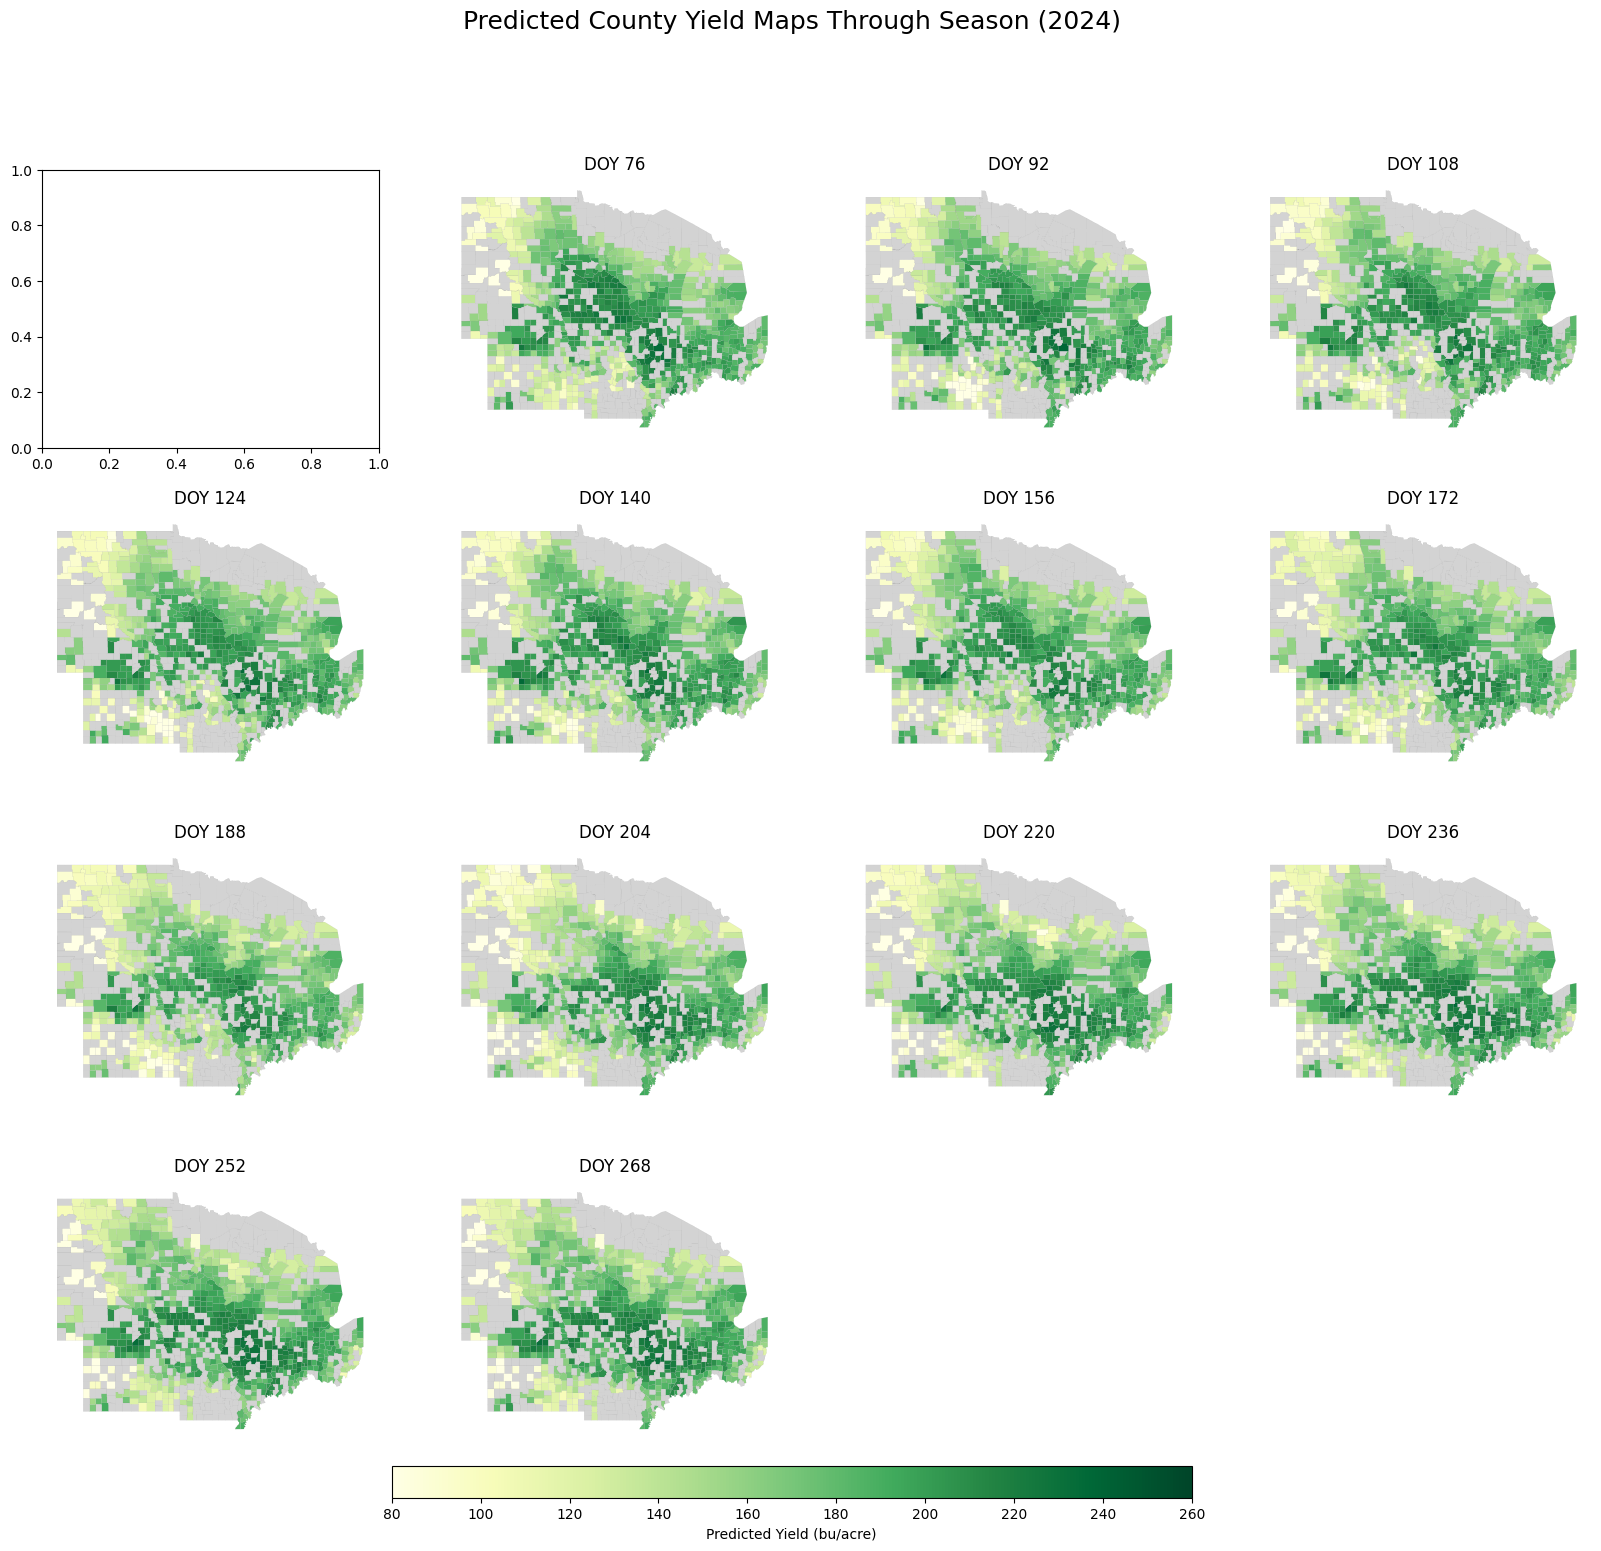

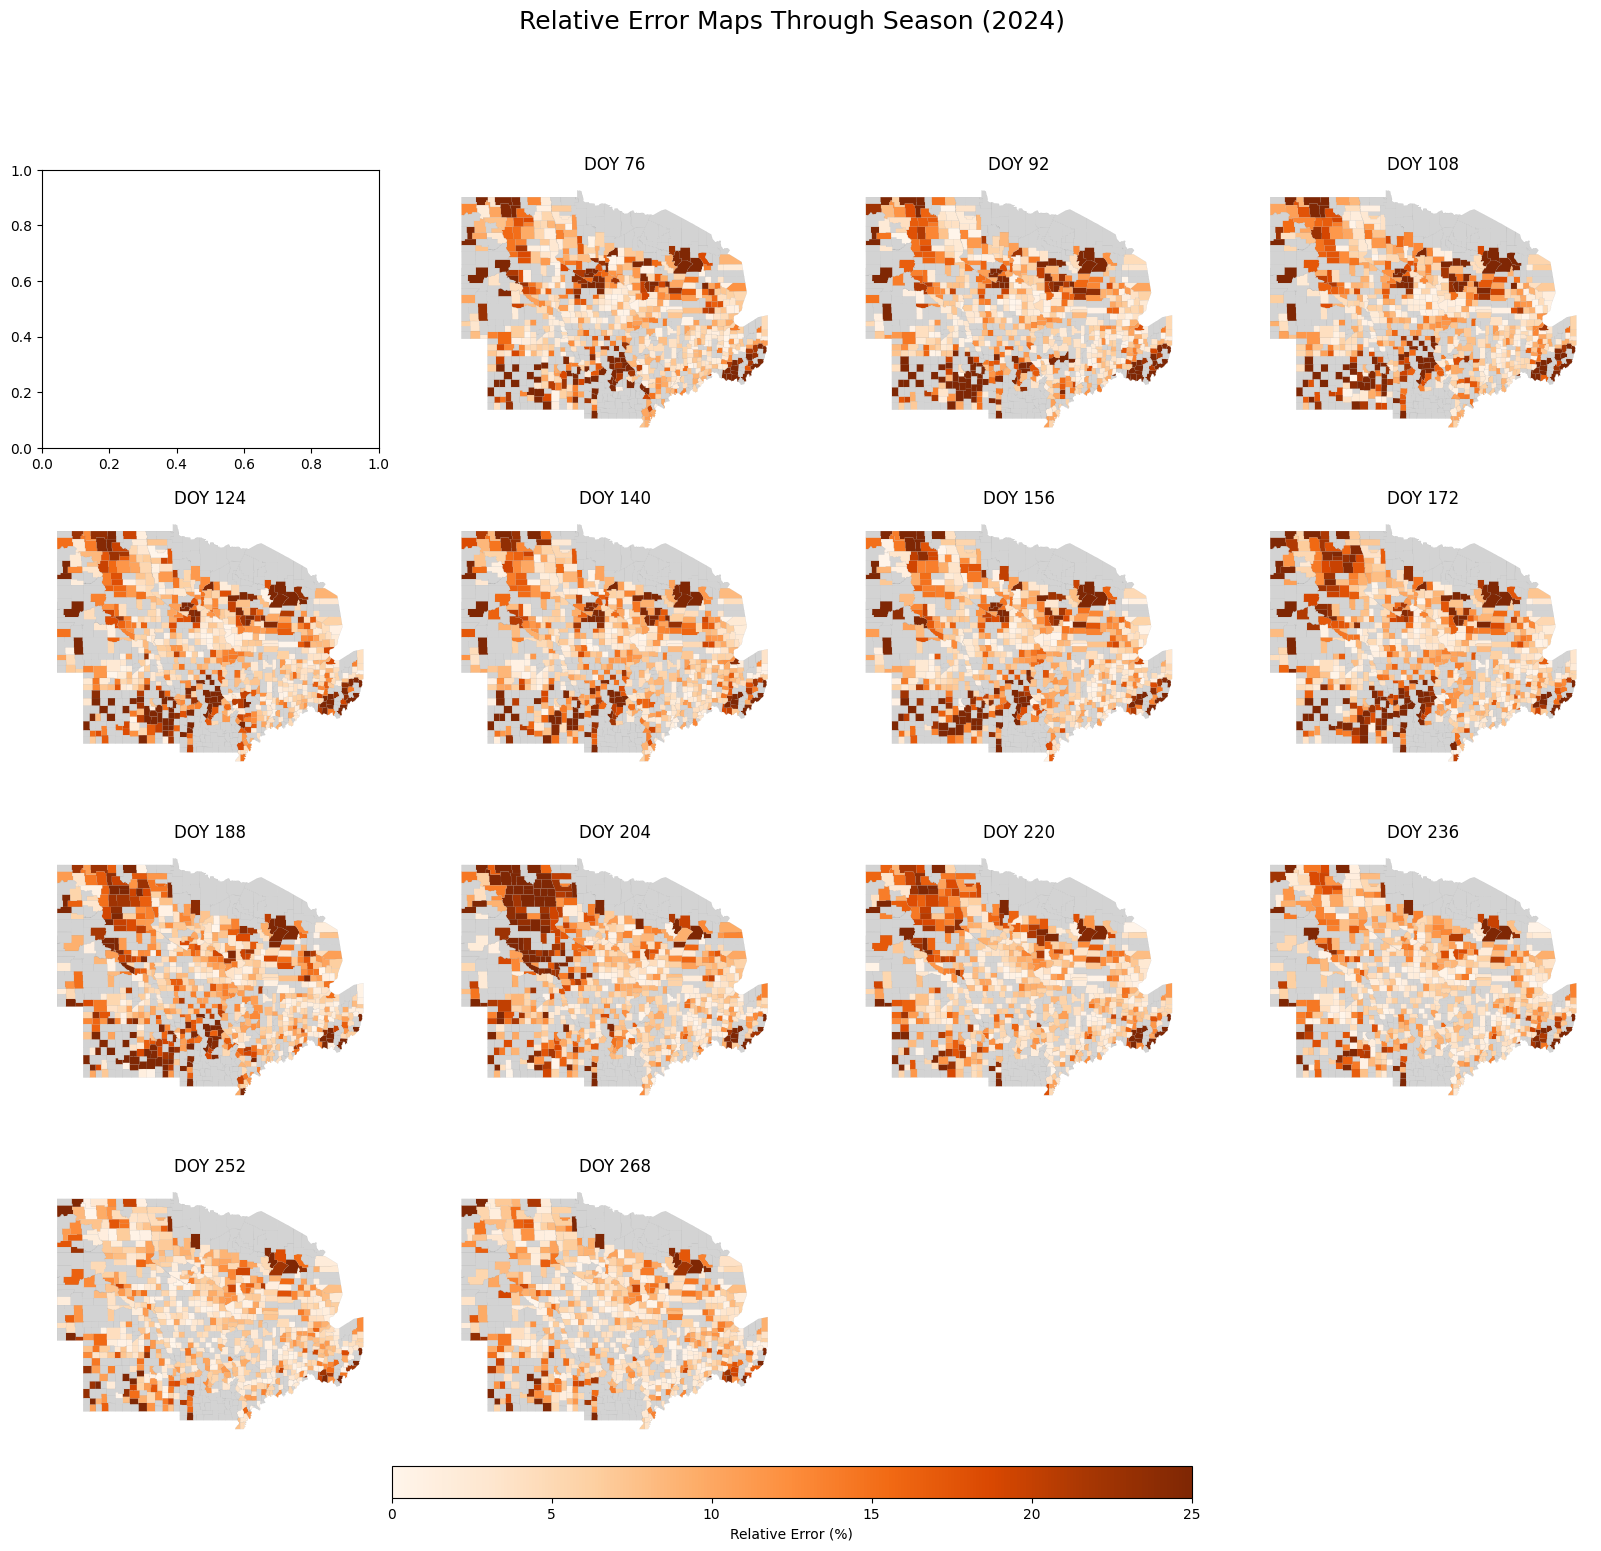

In [57]:

# ============================================================
# SEASONAL YIELD + ERROR MAPS THROUGH THE YEAR
# Includes shared colorbars and fixed scales
# One panel per 16-day DOY cutoff
# ============================================================



# ============================================================
# SETTINGS
# ============================================================

TEST_YEAR = 2024
DOY_LIST = list(range(60, 275, 16))

# ============================================================
# LEAKAGE COLUMNS
# ============================================================

leakage_cols = [
    "yield_bu_acre",
    "yield_filled",
    "yield_anomaly",
    "target",
    "yield"
]

# ============================================================
# FIND COUNTY ID COLUMN
# ============================================================

possible_fips_cols = [
    "FIPS",
    "fips",
    "GEOID",
    "geoid",
    "county_fips",
    "CountyFIPS"
]

fips_col = None
for col in possible_fips_cols:
    if col in df_prev_cdl.columns:
        fips_col = col
        break

print("Using county ID column:", fips_col)

# ============================================================
# CREATE PANEL FIGURES
# ============================================================

ncols = 4
nrows = int(np.ceil(len(DOY_LIST) / ncols))

fig_yield, axes_yield = plt.subplots(
    nrows,
    ncols,
    figsize=(20, 4 * nrows)
)

fig_error, axes_error = plt.subplots(
    nrows,
    ncols,
    figsize=(20, 4 * nrows)
)

axes_yield = axes_yield.flatten()
axes_error = axes_error.flatten()

# ============================================================
# LOOP THROUGH DOYS
# ============================================================

for i, doy_cut in enumerate(DOY_LIST):

    print(f"Running DOY {doy_cut}")

    # ------------------------------------------------
    # TRAIN / TEST SPLIT
    # ------------------------------------------------

    train_df = df_same_cdl[
        df_same_cdl["year"] < TEST_YEAR
    ].copy()

    test_df = df_prev_cdl[
        df_prev_cdl["year"] == TEST_YEAR
    ].copy()

    X_train = build_features(train_df, doy_cut)
    X_test = build_features(test_df, doy_cut)

    if X_train.empty or X_test.empty:
        print(f"Skipping DOY {doy_cut} because features are empty")
        continue

    # ------------------------------------------------
    # REMOVE LEAKAGE COLUMNS
    # ------------------------------------------------

    X_train = X_train.drop(
        columns=[c for c in leakage_cols if c in X_train.columns],
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=[c for c in leakage_cols if c in X_test.columns],
        errors="ignore"
    )

    # ------------------------------------------------
    # ADD SAFE FEATURES
    # ------------------------------------------------

    X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
    X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

    # Uncomment if you want to include year as a feature
    # X_train["year"] = train_df.loc[X_train.index, "year"]
    # X_test["year"] = test_df.loc[X_test.index, "year"]

    # ------------------------------------------------
    # FILL MISSING VALUES
    # ------------------------------------------------

    medians = X_train.median()

    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)

    # ------------------------------------------------
    # TARGET = YIELD ANOMALY
    # ------------------------------------------------

    y_train = (
        train_df.loc[X_train.index, "yield_filled"] -
        train_df.loc[X_train.index, "hist_5yr"]
    )

    # ------------------------------------------------
    # MODEL
    # ------------------------------------------------

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_anomaly = model.predict(X_test)

    pred_yield = (
        test_df.loc[X_test.index, "hist_5yr"].values +
        pred_anomaly
    )

    # ------------------------------------------------
    # BUILD COUNTY RESULTS
    # ------------------------------------------------

    temp_results = test_df.loc[
        X_test.index,
        [fips_col, "yield_bu_acre"]
    ].copy()

    temp_results = temp_results.rename(
        columns={fips_col: "FIPS"}
    )

    temp_results["FIPS"] = (
        temp_results["FIPS"]
        .astype(str)
        .str.zfill(5)
    )

    temp_results["predicted_bu_acre"] = pred_yield

    temp_results["abs_error_bu_acre"] = np.abs(
        temp_results["predicted_bu_acre"] -
        temp_results["yield_bu_acre"]
    )

    temp_results["relative_error_pct"] = (
        temp_results["abs_error_bu_acre"] /
        temp_results["yield_bu_acre"]
    ) * 100

    # ------------------------------------------------
    # MERGE WITH COUNTY SHAPES
    # ------------------------------------------------

    temp_map = county_shapes.merge(
        temp_results,
        on="FIPS",
        how="left"
    )

    # ------------------------------------------------
    # PLOT YIELD MAP
    # ------------------------------------------------

    temp_map.plot(
        column="predicted_bu_acre",
        cmap="YlGn",
        linewidth=0.05,
        edgecolor="gray",
        ax=axes_yield[i],
        legend=False,
        vmin=80,
        vmax=260,
        missing_kwds={"color": "lightgray"}
    )

    axes_yield[i].set_title(f"DOY {doy_cut}")
    axes_yield[i].axis("off")

    # ------------------------------------------------
    # PLOT ERROR MAP
    # ------------------------------------------------

    temp_map.plot(
        column="relative_error_pct",
        cmap="Oranges",
        linewidth=0.05,
        edgecolor="gray",
        ax=axes_error[i],
        legend=False,
        vmin=0,
        vmax=25,
        missing_kwds={"color": "lightgray"}
    )

    axes_error[i].set_title(f"DOY {doy_cut}")
    axes_error[i].axis("off")

# ============================================================
# TURN OFF EXTRA EMPTY PANELS
# ============================================================

for j in range(len(DOY_LIST), len(axes_yield)):
    axes_yield[j].axis("off")
    axes_error[j].axis("off")

# ============================================================
# FINAL FORMATTING
# ============================================================

fig_yield.suptitle(
    f"Predicted County Yield Maps Through Season ({TEST_YEAR})",
    fontsize=18,
    y=0.98
)

fig_error.suptitle(
    f"Relative Error Maps Through Season ({TEST_YEAR})",
    fontsize=18,
    y=0.98
)

# Leave room at bottom for colorbars
fig_yield.subplots_adjust(bottom=0.08)
fig_error.subplots_adjust(bottom=0.08)

# ============================================================
# CREATE COLOR SC


# ============================================================
# ADD SHARED COLORBARS TO THE BOTTOM
# ============================================================

# 1. Colorbar for Yield Figure
# Define the range and colormap to match your plot settings
norm_yield = mcolors.Normalize(vmin=80, vmax=260)
sm_yield = cm.ScalarMappable(cmap="YlGn", norm=norm_yield)

# Create an axis for the colorbar: [left, bottom, width, height]
cbar_ax_yield = fig_yield.add_axes([0.3, 0.05, 0.4, 0.02]) 
fig_yield.colorbar(
    sm_yield, 
    cax=cbar_ax_yield, 
    orientation='horizontal', 
    label="Predicted Yield (bu/acre)"
)

# 2. Colorbar for Error Figure
norm_error = mcolors.Normalize(vmin=0, vmax=25)
sm_error = cm.ScalarMappable(cmap="Oranges", norm=norm_error)

cbar_ax_error = fig_error.add_axes([0.3, 0.05, 0.4, 0.02])
fig_error.colorbar(
    sm_error, 
    cax=cbar_ax_error, 
    orientation='horizontal', 
    label="Relative Error (%)"
)

plt.show()



In [43]:
# ============================================================
# R2 / RMSE THROUGH THE SEASON
# ============================================================

performance_results = []

DOY_LIST = list(range(60, 275, 16))

for doy_cut in DOY_LIST:

    train_df = df_same_cdl[
        df_same_cdl["year"] < TEST_YEAR
    ].copy()

    test_df = df_prev_cdl[
        df_prev_cdl["year"] == TEST_YEAR
    ].copy()

    X_train = build_features(train_df, doy_cut)
    X_test = build_features(test_df, doy_cut)

    if X_train.empty or X_test.empty:
        continue

    X_train = X_train.drop(
        columns=[c for c in leakage_cols if c in X_train.columns],
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=[c for c in leakage_cols if c in X_test.columns],
        errors="ignore"
    )

    X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
    X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

    X_train["year"] = train_df.loc[X_train.index, "year"]
    X_test["year"] = test_df.loc[X_test.index, "year"]

    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test = X_test.fillna(medians)

    y_train = (
        train_df.loc[X_train.index, "yield_filled"] -
        train_df.loc[X_train.index, "hist_5yr"]
    )

    y_test = test_df.loc[X_test.index, "yield_bu_acre"]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred_anomaly = model.predict(X_test)

    pred_yield = (
        test_df.loc[X_test.index, "hist_5yr"].values +
        pred_anomaly
    )

    r2 = r2_score(y_test, pred_yield)
    rmse = np.sqrt(mean_squared_error(y_test, pred_yield))

    performance_results.append({
        "DOY": doy_cut,
        "R2": r2,
        "RMSE": rmse
    })

performance_df = pd.DataFrame(performance_results)
display(performance_df)

,DOY,R2,RMSE
0,76,0.637513,21.394582
1,92,0.659758,20.727705
2,108,0.658962,20.751960
3,124,0.651594,20.974922
4,140,0.666908,20.508759
5,156,0.696775,19.567720
6,172,0.677617,20.176392
7,188,0.701639,19.410126
8,204,0.612170,22.129826
9,220,0.741650,18.061837


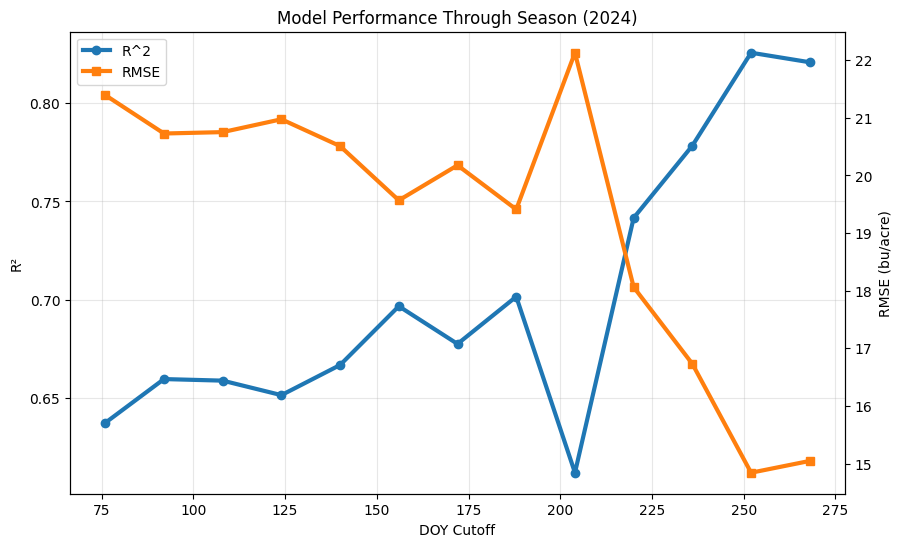

In [55]:
# ============================================================
# PLOT PERFORMANCE THROUGH THE SEASON
# ============================================================

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    performance_df["DOY"],
    performance_df["R2"],
    marker="o",
    linewidth=3,
    label="R^2",
    color = "tab:blue"
)

ax1.set_xlabel("DOY Cutoff")
ax1.set_ylabel("R²")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    performance_df["DOY"],
    performance_df["RMSE"],
    marker="s",
    linewidth=3,
    label="RMSE",
    color = "tab:orange"
)

ax2.set_ylabel("RMSE (bu/acre)")

plt.title(f"Model Performance Through Season ({TEST_YEAR})")
# 1. Collect handles and labels from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 2. Combine them and create a single legend
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.show()


===== DOY 65 =====

===== DOY 81 =====

===== DOY 97 =====

===== DOY 113 =====

===== DOY 129 =====

===== DOY 145 =====

===== DOY 161 =====

===== DOY 177 =====

===== DOY 193 =====

===== DOY 209 =====

===== DOY 225 =====

===== DOY 241 =====

===== DOY 257 =====

===== DOY 273 =====

Top Average Feature Importance Across Entire Season


,feature,importance
0,year,0.108293
1,NIRv_anom_mean,0.087328
2,EVI2_anom_last,0.063185
3,EVI2_anom_mean,0.039610
4,NIRv_anom_last,0.037323
5,EVI_scaled_anom_last,0.037114
6,NIRv_anom_slope,0.030676
7,EVI2_anom_slope,0.027586
8,GCI_anom_mean,0.022401
9,NDWI_peak_doy,0.022127


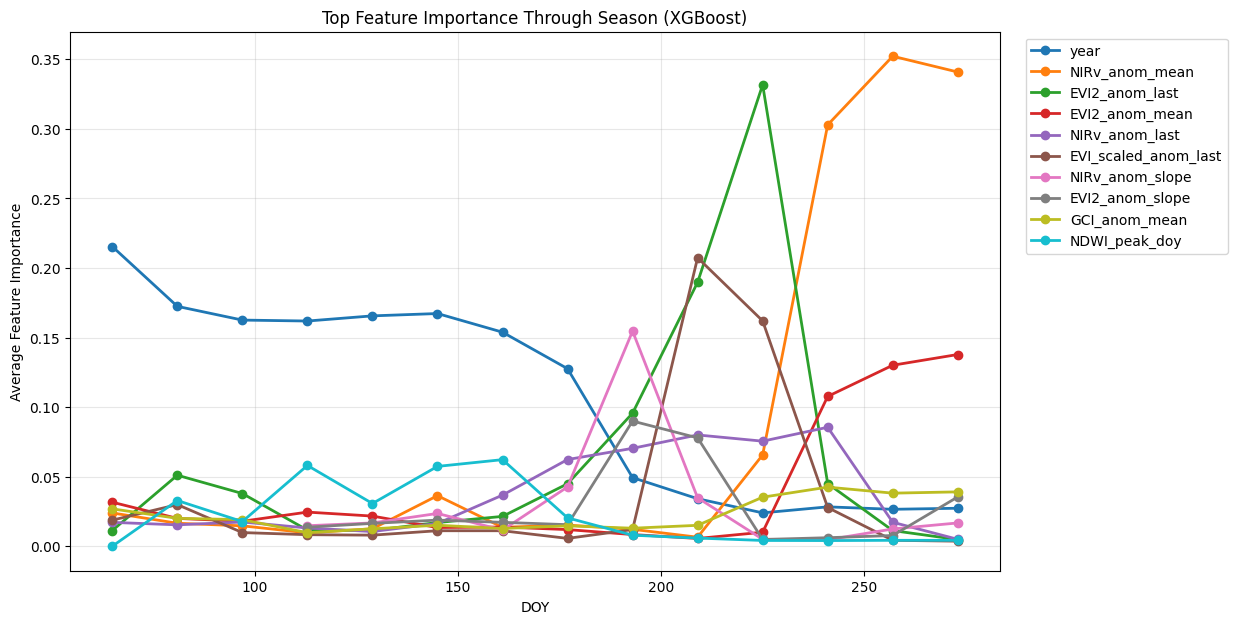

In [45]:
# ============================================================
# XGBOOST FEATURE IMPORTANCE THROUGH SEASON
# ============================================================



TEST_YEARS = list(range(2020, 2025))

importance_rows = []

for doy_cut in range(65, 274, 16):

    print(f"\n===== DOY {doy_cut} =====")

    for yr in TEST_YEARS:

        # ------------------------------------------------
        # TRAIN / TEST SPLIT
        # ------------------------------------------------

        train_df = df_same_cdl[
            df_same_cdl["year"] < yr
        ].copy()

        test_df = df_prev_cdl[
            df_prev_cdl["year"] == yr
        ].copy()

        X_train = build_features(train_df, doy_cut)
        X_test = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            continue

        # ------------------------------------------------
        # REMOVE LEAKAGE COLUMNS
        # ------------------------------------------------

        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(
            columns=[c for c in leakage_cols if c in X_train.columns],
            errors="ignore"
        )

        X_test = X_test.drop(
            columns=[c for c in leakage_cols if c in X_test.columns],
            errors="ignore"
        )

        # ------------------------------------------------
        # ADD SAFE FEATURES
        # ------------------------------------------------

        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

        X_train["year"] = train_df.loc[X_train.index, "year"]
        X_test["year"] = test_df.loc[X_test.index, "year"]

        # ------------------------------------------------
        # FILL MISSING VALUES
        # ------------------------------------------------

        medians = X_train.median()

        X_train = X_train.fillna(medians)
        X_test = X_test.fillna(medians)

        # ------------------------------------------------
        # TARGET = YIELD ANOMALY
        # ------------------------------------------------

        y_train = (
            train_df.loc[X_train.index, "yield_filled"] -
            train_df.loc[X_train.index, "hist_5yr"]
        )

        # ------------------------------------------------
        # MODEL
        # ------------------------------------------------

        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, y_train)

        temp_importance = pd.DataFrame({
            "feature": X_train.columns,
            "importance": model.feature_importances_,
            "DOY": doy_cut,
            "test_year": yr
        })

        importance_rows.append(temp_importance)

# ============================================================
# COMBINE RESULTS
# ============================================================

importance_df = pd.concat(importance_rows, ignore_index=True)

# ============================================================
# AVERAGE IMPORTANCE BY FEATURE + DOY
# ============================================================

importance_summary = (
    importance_df
    .groupby(["DOY", "feature"])["importance"]
    .mean()
    .reset_index()
)

# ============================================================
# TOP FEATURES OVERALL
# ============================================================

overall_summary = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\nTop Average Feature Importance Across Entire Season")
display(overall_summary.head(20))

# ============================================================
# PLOT TOP 10 FEATURES THROUGH SEASON
# ============================================================

top_features = overall_summary.head(10)["feature"].tolist()

plt.figure(figsize=(12, 7))

for feature in top_features:

    temp = importance_summary[
        importance_summary["feature"] == feature
    ]

    plt.plot(
        temp["DOY"],
        temp["importance"],
        marker="o",
        linewidth=2,
        label=feature
    )

plt.xlabel("DOY")
plt.ylabel("Average Feature Importance")
plt.title("Top Feature Importance Through Season (XGBoost)")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [46]:
# ============================================================
# IMPROVED COUNTY MAPS WITH COLOR SCALES
# ============================================================



# Fixed scales for consistency through season
yield_vmin = 80
yield_vmax = 260

error_vmin = 0
error_vmax = 25

yield_norm = Normalize(vmin=yield_vmin, vmax=yield_vmax)
error_norm = Normalize(vmin=error_vmin, vmax=error_vmax)

yield_sm = ScalarMappable(norm=yield_norm, cmap="YlGn")
yield_sm.set_array([])

error_sm = ScalarMappable(norm=error_norm, cmap="Oranges")
error_sm.set_array([])

# Add colorbars
cbar_yield = fig_yield.colorbar(
    yield_sm,
    ax=axes_yield.tolist(),
    orientation="horizontal",
    fraction=0.025,
    pad=0.02
)

cbar_yield.set_label("Predicted Yield (bu/ac)", fontsize=12)

cbar_error = fig_error.colorbar(
    error_sm,
    ax=axes_error.tolist(),
    orientation="horizontal",
    fraction=0.025,
    pad=0.02
)

cbar_error.set_label("Absolute Relative Error (%)", fontsize=12)

fig_yield.tight_layout(rect=[0, 0.05, 1, 0.97])
fig_error.tight_layout(rect=[0, 0.05, 1, 0.97])

plt.show()

In [47]:
# ============================================================
# ADD COLORBARS AFTER THE MAPS ARE ALREADY DRAWN
# ============================================================


# Rebuild color scales
yield_norm = Normalize(vmin=80, vmax=260)
error_norm = Normalize(vmin=0, vmax=25)

yield_sm = ScalarMappable(norm=yield_norm, cmap="YlGn")
yield_sm.set_array([])

error_sm = ScalarMappable(norm=error_norm, cmap="Oranges")
error_sm.set_array([])

# Add yield colorbar
fig_yield.subplots_adjust(bottom=0.08)

cax_yield = fig_yield.add_axes([0.25, 0.03, 0.5, 0.015])

cbar_yield = fig_yield.colorbar(
    yield_sm,
    cax=cax_yield,
    orientation="horizontal"
)

cbar_yield.set_label("Predicted Yield (bu/ac)")

# Add error colorbar
fig_error.subplots_adjust(bottom=0.08)

cax_error = fig_error.add_axes([0.25, 0.03, 0.5, 0.015])

cbar_error = fig_error.colorbar(
    error_sm,
    cax=cax_error,
    orientation="horizontal"
)

cbar_error.set_label("Absolute Relative Error (%)")

plt.show()

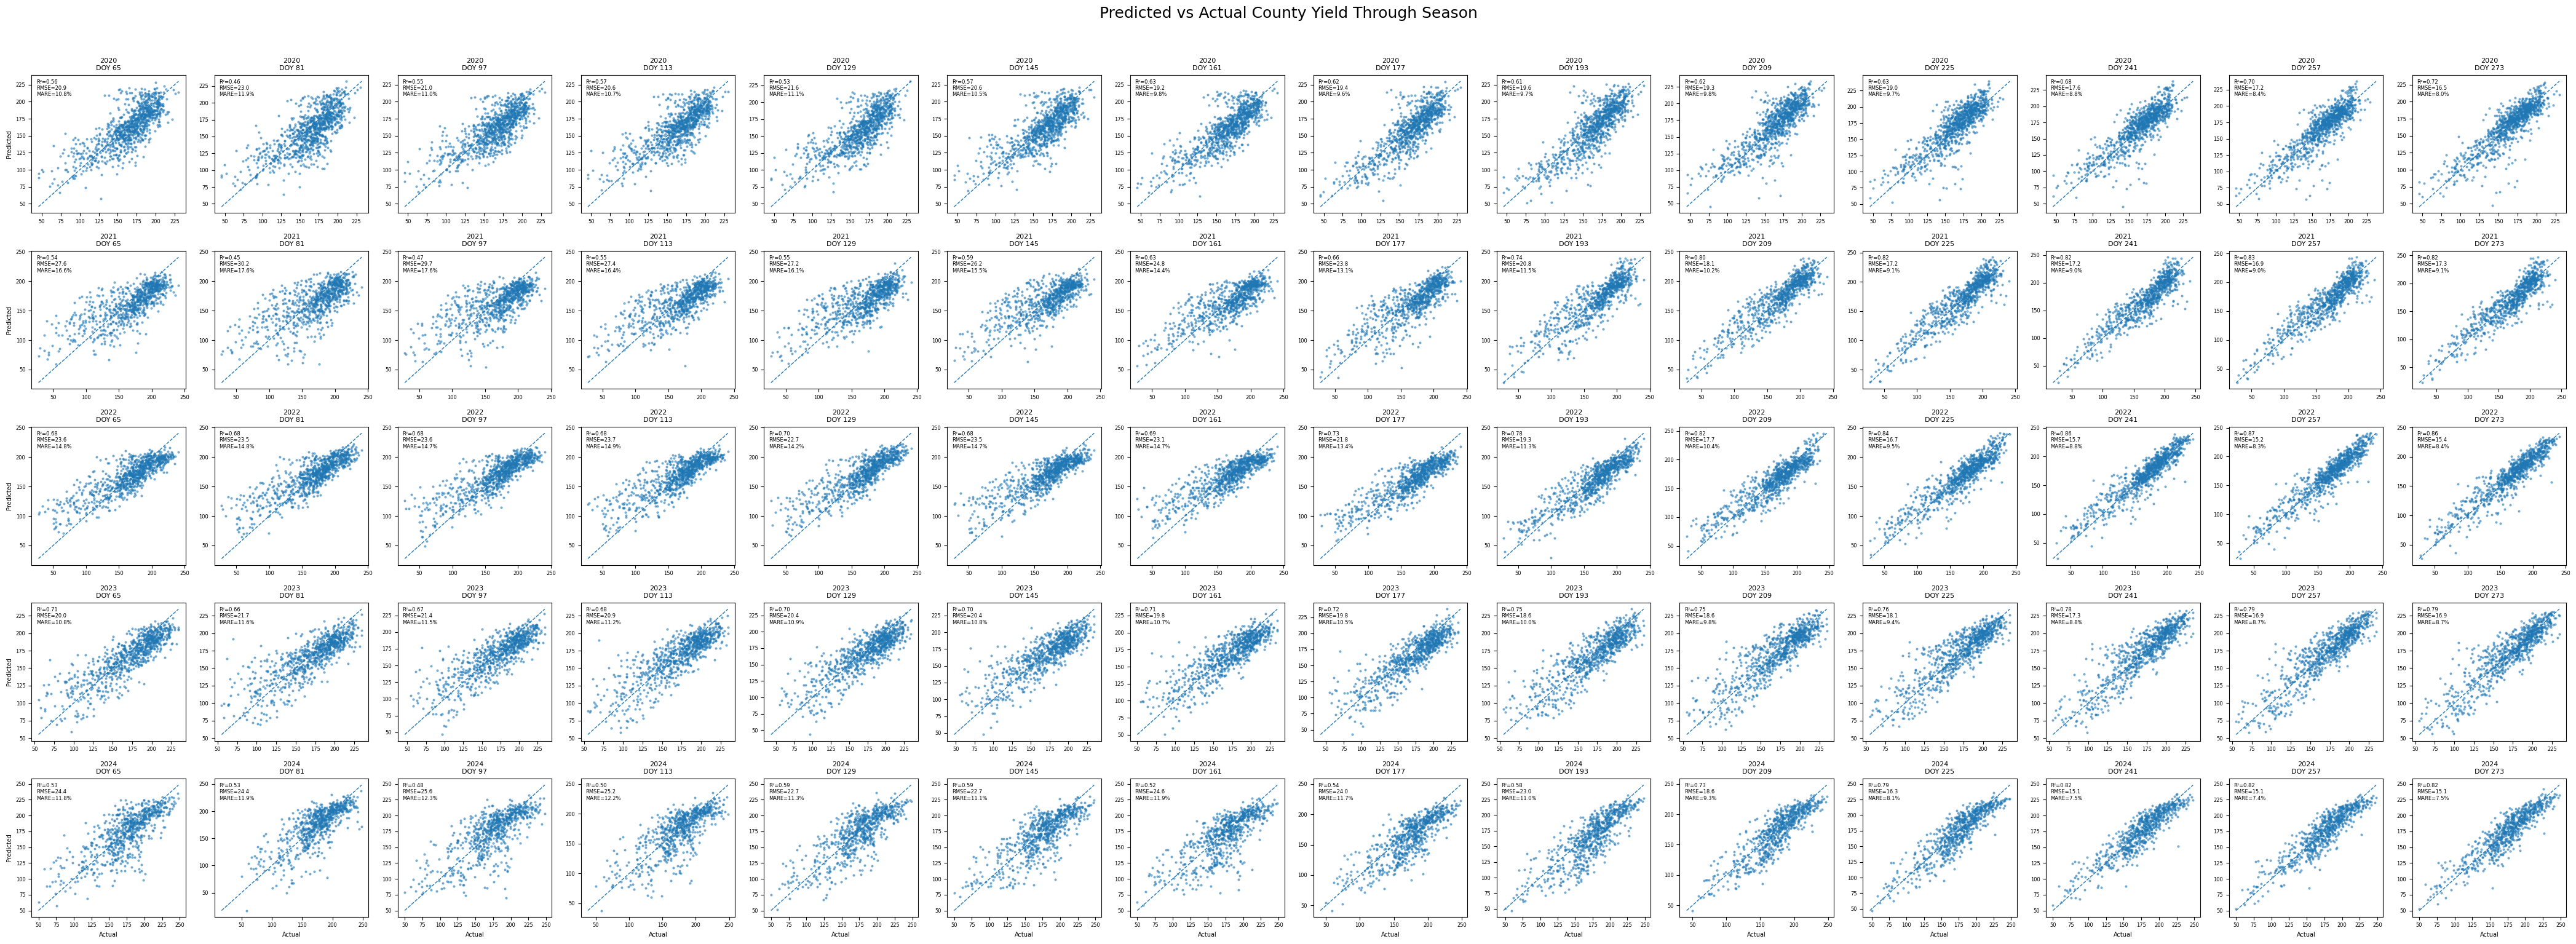

In [48]:

# ============================================================
# SCATTER PLOTS: PREDICTED VS ACTUAL FOR MULTIPLE TEST YEARS
# One panel for every 16-day DOY cutoff
# ============================================================



plot_years = [2020, 2021, 2022, 2023, 2024]
selected_doys = list(range(65, 274, 16))

nrows = len(plot_years)
ncols = len(selected_doys)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(3 * ncols, 3 * nrows)
)

for row, yr in enumerate(plot_years):

    for col, doy_cut in enumerate(selected_doys):

        ax = axes[row, col]

        train_df = df_same_cdl[
            df_same_cdl["year"] < yr
        ].copy()

        test_df = df_prev_cdl[
            df_prev_cdl["year"] == yr
        ].copy()

        X_train = build_features(train_df, doy_cut)
        X_test = build_features(test_df, doy_cut)

        if X_train.empty or X_test.empty:
            ax.axis("off")
            continue

        # ------------------------------------------------
        # REMOVE LEAKAGE COLUMNS
        # ------------------------------------------------

        leakage_cols = [
            "yield_bu_acre",
            "yield_filled",
            "yield_anomaly",
            "target",
            "yield"
        ]

        X_train = X_train.drop(
            columns=[c for c in leakage_cols if c in X_train.columns],
            errors="ignore"
        )

        X_test = X_test.drop(
            columns=[c for c in leakage_cols if c in X_test.columns],
            errors="ignore"
        )

        # ------------------------------------------------
        # ADD SAFE FEATURES
        # ------------------------------------------------

        X_train["hist_5yr"] = train_df.loc[X_train.index, "hist_5yr"]
        X_test["hist_5yr"] = test_df.loc[X_test.index, "hist_5yr"]

        # Optional
        # X_train["year"] = train_df.loc[X_train.index, "year"]
        # X_test["year"] = test_df.loc[X_test.index, "year"]

        # ------------------------------------------------
        # FILL MISSING VALUES
        # ------------------------------------------------

        medians = X_train.median()
        X_train = X_train.fillna(medians)
        X_test = X_test.fillna(medians)

        # ------------------------------------------------
        # TARGET = YIELD ANOMALY
        # ------------------------------------------------

        y_train = (
            train_df.loc[X_train.index, "yield_filled"] -
            train_df.loc[X_train.index, "hist_5yr"]
        )

        y_test = test_df.loc[X_test.index, "yield_bu_acre"].values

        # ------------------------------------------------
        # MODEL
        # ------------------------------------------------

        model = XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        model.fit(X_train, y_train)

        pred_anomaly = model.predict(X_test)

        pred_yield = (
            test_df.loc[X_test.index, "hist_5yr"].values +
            pred_anomaly
        )

        # ------------------------------------------------
        # METRICS
        # ------------------------------------------------

        r2 = r2_score(y_test, pred_yield)
        rmse = np.sqrt(mean_squared_error(y_test, pred_yield))
        mare = np.mean(np.abs(pred_yield - y_test) / y_test) * 100

        # ------------------------------------------------
        # SCATTER PLOT
        # ------------------------------------------------

        ax.scatter(
            y_test,
            pred_yield,
            s=4,
            alpha=0.5
        )

        min_val = min(y_test.min(), pred_yield.min())
        max_val = max(y_test.max(), pred_yield.max())

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            linestyle="--",
            linewidth=1
        )

        ax.set_title(
            f"{yr}\nDOY {doy_cut}",
            fontsize=8
        )

        ax.text(
            0.03,
            0.97,
            f"R²={r2:.2f}\nRMSE={rmse:.1f}\nMARE={mare:.1f}%",
            transform=ax.transAxes,
            verticalalignment="top",
            fontsize=6
        )

        ax.tick_params(labelsize=6)

        if row == nrows - 1:
            ax.set_xlabel("Actual", fontsize=7)

        if col == 0:
            ax.set_ylabel("Predicted", fontsize=7)

plt.suptitle(
    "Predicted vs Actual County Yield Through Season",
    fontsize=18,
    y=1.02
)

plt.tight_layout()
plt.show()

